Cell 1 — Imports (pure BYOL SSL)

In [5]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import gc, json, math, pickle, contextlib, warnings, time, random, copy
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import DataLoader, Batch
from torch_geometric.nn import GATConv, GlobalAttention
from torch.cuda.amp import GradScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (f1_score, silhouette_score,roc_auc_score, average_precision_score,confusion_matrix)
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import global_mean_pool
from tqdm import tqdm
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True 
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')
warnings.filterwarnings('ignore')

Cell 2 — Config (pure BYOL, no labels)

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

HIDDEN_DIM        = 128
NUM_HEADS         = 4
NUM_LAYERS        = 3

PROJECTION_DIM    = 128
PREDICTOR_HID     = 256

BATCH_SIZE        = 128        
GRAD_ACCUM_STEPS  = 2
LEARNING_RATE     = 3e-4
WEIGHT_DECAY      = 1e-4
EPOCHS            = 100
EVAL_INTERVAL     = 5
EARLY_STOP        = 40          

BYOL_MOMENTUM_BASE  = 0.996
BYOL_MOMENTUM_FINAL = 1.0

USE_MASKED_RECON  = True
RECON_MASK_RATIO  = 0.30
RECON_WEIGHT = 0.05

# ---- graph caps (MUST match graph_making pickles and TFT) ----
MAX_NODES         = 128
MAX_EDGES         = 20000

KNN_K             = 10
SEED              = 42
PROBE_TRAIN_MAX   = 4000

DATASET_THRESHOLDS = {
    'gotham':  0.08,
    'nf_ton':  0.15,
    'nf_bot':  0.10,
}

EDGE_DROPOUT_MAP = {'gotham': 0.10, 'nf_ton': 0.10, 'nf_bot': 0.05}
FEATURE_MASK_MAP = {'gotham': 0.10, 'nf_ton': 0.10, 'nf_bot': 0.05}
NODE_DROP_MAP    = {'gotham': 0.05, 'nf_ton': 0.05, 'nf_bot': 0.02}
SUBGRAPH_MAP     = {'gotham': 0.90, 'nf_ton': 0.90, 'nf_bot': 0.95}

BLACKLIST_CLASSES = {'Unknown', 'unknown', 'UNKNOWN'}
NUM_WORKERS     = 0
PREFETCH_FACTOR = 2

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"PURE BYOL SSL — no labels, no aux classifier")
print(f"  encoder   : {NUM_LAYERS} GAT layers, {NUM_HEADS} heads, hid {HIDDEN_DIM}")
print(f"  proj dim  : {PROJECTION_DIM}   predictor hidden: {PREDICTOR_HID}")
print(f"  EMA       : {BYOL_MOMENTUM_BASE} -> {BYOL_MOMENTUM_FINAL} (cosine)")
print(f"  recon     : {USE_MASKED_RECON}  mask={RECON_MASK_RATIO}  w={RECON_WEIGHT}")
print(f"  LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  BS={BATCH_SIZE}  EPOCHS={EPOCHS}")
print(f"  caps      : MAX_NODES={MAX_NODES}  MAX_EDGES={MAX_EDGES}")
print(f"  augment (edge/feat/node/sub):")
for k in DATASET_THRESHOLDS:
    print(f"    {k:8s} {EDGE_DROPOUT_MAP[k]:.2f} / {FEATURE_MASK_MAP[k]:.2f} / "
          f"{NODE_DROP_MAP[k]:.2f} / {SUBGRAPH_MAP[k]:.2f}")

Device: cuda
PURE BYOL SSL — no labels, no aux classifier
  encoder   : 3 GAT layers, 4 heads, hid 128
  proj dim  : 128   predictor hidden: 256
  EMA       : 0.996 -> 1.0 (cosine)
  recon     : True  mask=0.3  w=0.05
  LR=0.0003  WD=0.0001  BS=128  EPOCHS=100
  caps      : MAX_NODES=128  MAX_EDGES=20000
  augment (edge/feat/node/sub):
    gotham   0.10 / 0.10 / 0.05 / 0.90
    nf_ton   0.10 / 0.10 / 0.05 / 0.90
    nf_bot   0.05 / 0.05 / 0.02 / 0.95


Cell 3 — Dataset registry

In [7]:
DATASET_CONFIG = {
    'gotham':   {'dir': 'Gotham_processed_features_10s/graphs'},
    'nf_ton':   {'dir': 'NFToNIoT_v3_10s/graphs'},
    'nf_bot':   {'dir': 'NFBoTIoT_v3_10s/graphs'},
}

Cell 4 — Autocast helper

In [8]:
if DEVICE.type == 'cuda':
    try:
        from torch.amp import autocast as _ac
        def autocast_ctx(): return _ac(device_type='cuda', dtype=torch.float16)
    except Exception:
        from torch.cuda.amp import autocast as _ac
        def autocast_ctx(): return _ac(enabled=True)
else:
    def autocast_ctx(): return contextlib.nullcontext()

Cell 5 — Graph utilities (identical interface to Phase 3)

In [9]:
def cap_graph(g, max_nodes=MAX_NODES, max_edges=MAX_EDGES):
    g = g.clone(); num_nodes = g.num_nodes
    if g.edge_index.size(1) > max_edges:
        keep = torch.randperm(g.edge_index.size(1))[:max_edges]
        g.edge_index = g.edge_index[:, keep]
        if g.edge_attr is not None and g.edge_attr.size(0) > 0:
            if g.edge_attr.dim() > 2:
                g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))
            g.edge_attr = g.edge_attr[keep]
    if num_nodes > max_nodes:
        deg = torch.zeros(num_nodes, dtype=torch.long)
        deg.scatter_add_(0, g.edge_index[0],
                         torch.ones(g.edge_index.size(1), dtype=torch.long))
        kn = torch.topk(deg, max_nodes).indices
        mask = torch.zeros(num_nodes, dtype=torch.bool); mask[kn] = True
        s, d = g.edge_index; keep_e = mask[s] & mask[d]
        g.edge_index = g.edge_index[:, keep_e]
        if g.edge_attr is not None and g.edge_attr.size(0) > 0:
            g.edge_attr = g.edge_attr[keep_e]
        remap = torch.zeros(num_nodes, dtype=torch.long)
        remap[mask] = torch.arange(max_nodes, dtype=torch.long)
        g.edge_index = remap[g.edge_index]; g.x = g.x[mask]
    return g


def dominant_family(g, attack_threshold=0.15,
                    blacklist=('Unknown', 'unknown', 'UNKNOWN')):
    names = getattr(g, 'edge_attack_names', None)
    if not names:
        return 'Benign'
    c = Counter(names); total = sum(c.values())
    atk = {k: v for k, v in c.items()
           if k != 'Benign' and k not in blacklist}
    if not atk:
        return 'Benign'
    atk_edges = sum(atk.values())
    if atk_edges / max(total, 1) < attack_threshold:
        return 'Benign'
    return max(atk, key=atk.get)


def size_aware_rate(num_edges, base_rate):
    if num_edges < 500:  return base_rate * 0.4
    if num_edges < 2000: return base_rate * 0.7
    return base_rate


def _rate_vec(edge_counts, base_rate):
    c = edge_counts.to(torch.float32)
    r = torch.full_like(c, base_rate)
    r = torch.where(c < 2000, c.new_full((), base_rate * 0.7), r)
    r = torch.where(c < 500,  c.new_full((), base_rate * 0.4), r)
    return r


def apply_node_subset(data, keep_ratio, clone=True):
    if clone:
        data = data.clone()
    num_nodes = data.num_nodes
    if num_nodes <= 1 or keep_ratio >= 1.0:
        return data
    dev = data.x.device
    keep_size = max(1, int(num_nodes * keep_ratio))
    perm = torch.randperm(num_nodes, device=dev)[:keep_size]
    mask = torch.zeros(num_nodes, dtype=torch.bool, device=dev)
    mask[perm] = True
    src, dst = data.edge_index
    keep_edges = mask[src] & mask[dst]
    data.edge_index = data.edge_index[:, keep_edges]
    if data.edge_attr is not None and data.edge_attr.numel() > 0:
        if data.edge_attr.dim() > 2:
            data.edge_attr = data.edge_attr.view(-1, data.edge_attr.size(-1))
        data.edge_attr = data.edge_attr[keep_edges]
    data.x = data.x[mask]
    node_idx = torch.zeros(num_nodes, dtype=torch.long, device=dev)
    node_idx[mask] = torch.arange(int(mask.sum()), device=dev)
    data.edge_index = node_idx[data.edge_index]
    return data


@torch.no_grad()
def augment_batch(batch, edge_drop, feat_mask, node_drop, subgraph):
    num_edges = batch.edge_index.size(1)
    device    = batch.edge_index.device
    num_nodes = batch.x.size(0)

    # ---- per-graph edge rates, indexed per-edge over the ORIGINAL edges ----
    if edge_drop > 0.0 and num_edges > 0:
        edge_graph  = batch.batch[batch.edge_index[0]]
        edge_counts = torch.bincount(edge_graph, minlength=batch.num_graphs)
        edge_rates  = _rate_vec(edge_counts, edge_drop)[edge_graph]  # len == num_edges
    else:
        edge_rates = None

    eff_feat = size_aware_rate(num_edges, feat_mask) if feat_mask > 0.0 else 0.0
    do_node  = (node_drop > 0.0) or (subgraph < 1.0)

    def _one(b):
        # ---------- 1) edge dropout FIRST (matches edge_rates length) ----------
        if edge_rates is not None and b.edge_index.size(1) > 0:
            keep = torch.rand(b.edge_index.size(1), device=device) >= edge_rates
            b.edge_index = b.edge_index[:, keep]
            if b.edge_attr is not None:
                b.edge_attr = b.edge_attr[keep]

        # ---------- 2) node / subgraph pruning (fully vectorised) ----------
        if do_node:
            keep_p    = max(0.0, (1.0 - node_drop) * subgraph)
            node_keep = torch.rand(num_nodes, device=device) < keep_p

            # guarantee >=1 node per graph
            if b.num_graphs > 1 or not bool(node_keep.any()):
                kept_per_graph = torch.bincount(
                    b.batch[node_keep], minlength=b.num_graphs)
                empty = (kept_per_graph == 0).nonzero(as_tuple=False).squeeze(1)
                if empty.numel() > 0:
                    first_idx = torch.full((b.num_graphs,), num_nodes,
                                           dtype=torch.long, device=device)
                    idx = torch.arange(num_nodes, device=device)
                    first_idx.scatter_reduce_(0, b.batch, idx,
                                              reduce='amin',
                                              include_self=True)
                    pick = (idx == first_idx[b.batch]) & \
                           (kept_per_graph[b.batch] == 0)
                    node_keep |= pick

            s, d  = b.edge_index
            ekeep = node_keep[s] & node_keep[d]

            b.edge_index = b.edge_index[:, ekeep]
            if b.edge_attr is not None and b.edge_attr.numel() > 0:
                b.edge_attr = b.edge_attr[ekeep]
            b.x     = b.x[node_keep]
            b.batch = b.batch[node_keep]

            remap = torch.full((num_nodes,), -1,
                               dtype=torch.long, device=device)
            n_keep = int(node_keep.sum())
            remap[node_keep] = torch.arange(n_keep, device=device)
            if b.edge_index.numel() > 0:
                b.edge_index = remap[b.edge_index]

        # ---------- 3) feature masking ----------
        if eff_feat > 0.0:
            b.x.masked_fill_(torch.rand(b.x.shape, device=device) < eff_feat, 0.0)
            if b.edge_attr is not None and b.edge_attr.numel() > 0:
                b.edge_attr.masked_fill_(
                    torch.rand(b.edge_attr.shape, device=device) < eff_feat, 0.0)

        # ---------- 4) safety for empty graphs / edges ----------
        if b.x.size(0) == 0:
            b.x = torch.zeros(1, batch.x.size(1),
                              device=device, dtype=batch.x.dtype)
            b.batch = torch.zeros(1, dtype=torch.long, device=device)
        if b.edge_index.size(1) == 0:
            b.edge_index = torch.empty(2, 0, device=device, dtype=torch.long)
            if b.edge_attr is not None:
                b.edge_attr = torch.empty(
                    0, b.edge_attr.size(-1),
                    device=device, dtype=b.edge_attr.dtype)
        return b

    b2 = _one(batch.clone())
    b1 = _one(batch)
    return b1, b2

Cell 6 — Module-level collate (graphs only — no labels)

In [10]:
def _collate_graphs_only(batch):
    return Batch.from_data_list(batch)

Cell 7 — Models (GATEncoder with node output, BYOL online/target, recon decoder)

In [11]:
class GATEncoder(nn.Module):
    def __init__(self, in_ch, hid, heads, layers, edge_dim):
        super().__init__()
        self.convs = nn.ModuleList(); self.bns = nn.ModuleList()
        self.convs.append(GATConv(in_ch, hid, heads=heads, edge_dim=edge_dim,
                                  concat=True, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hid * heads))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hid * heads, hid, heads=heads,
                                      edge_dim=edge_dim, concat=True, dropout=0.0))
            self.bns.append(nn.BatchNorm1d(hid * heads))
        self.convs.append(GATConv(hid * heads, hid, heads=1, edge_dim=edge_dim,
                                  concat=False, dropout=0.0))
        self.bns.append(nn.BatchNorm1d(hid))
        self.edge_dim = edge_dim
        self.pool_gate = nn.Sequential(
            nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, x, ei, ea=None, b=None, return_nodes=False):
        for i, c in enumerate(self.convs):
            x = c(x, ei, edge_attr=ea) if (ea is not None and self.edge_dim > 0) \
                else c(x, ei)
            x = F.relu(self.bns[i](x))
        h = GlobalAttention(self.pool_gate)(x, b)
        if return_nodes:
            return x, h
        return h


class BYOLModel(nn.Module):
    def __init__(self, in_ch, hid, heads, layers, edge_dim, proj_dim,
                 predictor_hid=256):
        super().__init__()
        self.encoder   = GATEncoder(in_ch, hid, heads, layers, edge_dim)
        self.projector = nn.Sequential(
            nn.Linear(hid, hid), nn.BatchNorm1d(hid), nn.ReLU(),
            nn.Linear(hid, proj_dim),
        )
        self.predictor = nn.Sequential(
            nn.Linear(proj_dim, predictor_hid), nn.BatchNorm1d(predictor_hid), nn.ReLU(),
            nn.Linear(predictor_hid, proj_dim),
        )

    def forward(self, x, ei, ea=None, b=None, predict=True, return_nodes=False):
        if return_nodes:
            h_nodes, h = self.encoder(x, ei, ea, b, return_nodes=True)
        else:
            h = self.encoder(x, ei, ea, b)
            h_nodes = None
        z = self.projector(h)
        if predict:
            p = self.predictor(z)
            return (h_nodes, h, z, p) if return_nodes else (h, z, p)
        return (h_nodes, h, z) if return_nodes else (h, z)


class MaskedReconDecoder(nn.Module):
    def __init__(self, hid, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, out_dim),
        )

    def forward(self, h_nodes):
        return self.net(h_nodes)

Cell 8 — BYOL loss + EMA helpers

In [12]:
def byol_momentum_schedule(step, total_steps,
                           base=BYOL_MOMENTUM_BASE, final=BYOL_MOMENTUM_FINAL):
    progress = min(step / max(total_steps - 1, 1), 1.0)
    return final - (final - base) * (math.cos(math.pi * progress) + 1.0) / 2.0


@torch.no_grad()
def update_momentum_encoder(target, online, m):
    t_params = list(target.parameters())
    o_params = list(online.parameters())
    torch._foreach_mul_(t_params, m)
    torch._foreach_add_(t_params, o_params, alpha=1 - m)
    online_bufs = dict(online.named_buffers())
    for name, tb in target.named_buffers():
        ob = online_bufs.get(name, None)
        if ob is None or tb.shape != ob.shape:
            continue
        if not tb.is_floating_point():
            if name.endswith('num_batches_tracked'):
                tb.data.copy_(ob.data)
            continue
        tb.data.mul_(m).add_(ob.data, alpha=1 - m)


def byol_loss(p, z):
    p = F.normalize(p, dim=-1, eps=1e-8)
    z = F.normalize(z.detach(), dim=-1, eps=1e-8)
    return 2.0 - 2.0 * (p * z).sum(dim=-1).mean()


def byol_symmetric_loss(p1, z1, p2, z2):
    return 0.5 * (byol_loss(p1, z2) + byol_loss(p2, z1))

Cell 9 — Frozen linear-probe evaluation (the correct SSL benchmark)

In [13]:
@torch.inference_mode()
def embed_graphs(encoder, graphs, device, batch_size=64):
    encoder.eval()
    chunks = []
    i = 0
    cur_bs = batch_size
    while i < len(graphs):
        chunk = graphs[i:i + cur_bs]
        try:
            batch = Batch.from_data_list(chunk).to(device)
            with autocast_ctx():
                out = encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            if isinstance(out, tuple):
                out = out[-1]
            arr = out.float().cpu().numpy()
            arr = np.nan_to_num(arr, nan=0.0, posinf=100.0, neginf=-100.0)
            chunks.append(arr)
            del batch, out
            i += cur_bs
            if device.type == 'cuda':
                torch.cuda.empty_cache()
        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and cur_bs > 1:
                torch.cuda.empty_cache()
                cur_bs = max(1, cur_bs // 2)
                continue
            raise
    return np.vstack(chunks)


def _optimal_threshold(prob, y):
    thrs = np.linspace(0.05, 0.95, 91)
    best_t, best_f1 = 0.5, -1.0
    for t in thrs:
        f1 = f1_score(y, (prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)


def _safe_f1(y_true, y_pred, average):
    try:
        return float(f1_score(y_true, y_pred, average=average, zero_division=0))
    except Exception:
        return 0.0


def frozen_linear_probe(encoder, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Binary frozen linear probe.
    Now returns BOTH binary F1 and macro / weighted F1 for val and test.
    """
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=100.0, neginf=-100.0)
    X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=100.0, neginf=-100.0)
    X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=100.0, neginf=-100.0)

    scaler = StandardScaler().fit(X_train)
    Xtr, Xva, Xte = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

    empty = {
        'val_roc': 0.0, 'test_roc': 0.0, 'test_pr': 0.0,
        'test_f1': 0.0, 'test_f1_binary': 0.0,
        'test_macro_f1': 0.0, 'test_weighted_f1': 0.0,
        'val_macro_f1': 0.0, 'val_weighted_f1': 0.0,
        'test_fpr': 0.0, 'test_fnr': 0.0,
        'threshold': 0.5, 'test_knn_roc': 0.0, 'val_silhouette': 0.0,
    }
    out = {}
    if len(set(y_train)) < 2:
        out.update(empty)
        return out

    lr = LogisticRegression(max_iter=3000, class_weight='balanced',
                            n_jobs=-1).fit(Xtr, y_train)
    prob_val  = lr.predict_proba(Xva)[:, 1]
    prob_test = lr.predict_proba(Xte)[:, 1]

    thr, _ = _optimal_threshold(prob_val, y_val)
    pred_val  = (prob_val  >= thr).astype(int)
    pred_test = (prob_test >= thr).astype(int)

    # --- ROC / PR ---
    out['val_roc']  = float(roc_auc_score(y_val, prob_val))
    out['test_roc'] = float(roc_auc_score(y_test, prob_test))
    out['test_pr']  = float(average_precision_score(y_test, prob_test))

    # --- F1 family: binary (positive class) + macro + weighted, for val & test ---
    out['test_f1']          = _safe_f1(y_test, pred_test, 'binary')
    out['test_f1_binary']   = out['test_f1']          # alias kept for summary cell
    out['test_macro_f1']    = _safe_f1(y_test, pred_test, 'macro')
    out['test_weighted_f1'] = _safe_f1(y_test, pred_test, 'weighted')
    out['val_macro_f1']     = _safe_f1(y_val,  pred_val,  'macro')
    out['val_weighted_f1']  = _safe_f1(y_val,  pred_val,  'weighted')

    # --- confusion matrix ---
    cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    out['test_fpr'] = float(cmn[0, 1])
    out['test_fnr'] = float(cmn[1, 0])
    out['threshold'] = float(thr)

    # --- KNN ROC ---
    try:
        knn = KNeighborsClassifier(n_neighbors=KNN_K, weights='distance',
                                   n_jobs=-1).fit(Xtr, y_train)
        out['test_knn_roc'] = float(roc_auc_score(y_test, knn.predict_proba(Xte)[:, 1]))
    except Exception:
        out['test_knn_roc'] = 0.0

    # --- silhouette ---
    if len(set(y_val)) > 1 and len(X_val) > 3:
        try:
            out['val_silhouette'] = float(silhouette_score(X_val, y_val, metric='cosine'))
        except Exception:
            out['val_silhouette'] = 0.0
    else:
        out['val_silhouette'] = 0.0

    return out

Cell 10 — Load dataset bundle (labels held aside for eval only)

In [14]:
BUNDLES = {}
def load_dataset_bundle(DATASET_NAME):
    if DATASET_NAME in BUNDLES:
        print(f"[cache] bundle '{DATASET_NAME}' already loaded")
        return BUNDLES[DATASET_NAME]

    DATA_DIR = DATASET_CONFIG[DATASET_NAME]['dir']
    CHECKPOINT_DIR = os.path.join(DATA_DIR, "ssl_checkpoints_byol")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    report_path  = os.path.join(CHECKPOINT_DIR, "ssl_report.json")
    encoder_path = os.path.join(CHECKPOINT_DIR, "ssl_encoder_best.pth")

    attack_threshold = DATASET_THRESHOLDS[DATASET_NAME]
    print(f"\n{'='*70}")
    print(f"Loading bundle — {DATASET_NAME}  |  threshold={attack_threshold}")
    print(f"{'='*70}")

    def load_graphs(split):
        with open(os.path.join(DATA_DIR, f"{split}_graphs.pkl"), 'rb') as f:
            return pickle.load(f)

    # ---- trust graph_making's class-wise chronological split ----
    train_graphs = [cap_graph(g) for g in load_graphs('train')]
    val_graphs   = [cap_graph(g) for g in load_graphs('val')]
    test_graphs  = [cap_graph(g) for g in load_graphs('test')]
    print(f"Loaded: train={len(train_graphs)} val={len(val_graphs)} test={len(test_graphs)}")

    def is_attack(g):
        return 0 if dominant_family(g, attack_threshold) == 'Benign' else 1

    train_bin = np.array([is_attack(g) for g in train_graphs], dtype=np.int64)
    val_bin   = np.array([is_attack(g) for g in val_graphs],   dtype=np.int64)
    test_bin  = np.array([is_attack(g) for g in test_graphs],  dtype=np.int64)

    # ---- diagnostics ----
    from collections import Counter as _C
    train_fam = [dominant_family(g, attack_threshold) for g in train_graphs]
    val_fam   = [dominant_family(g, attack_threshold) for g in val_graphs]
    test_fam  = [dominant_family(g, attack_threshold) for g in test_graphs]
    tr_dist = _C(train_fam); va_dist = _C(val_fam); te_dist = _C(test_fam)

    print("\nClass distribution per split (from graph_making pickles)")
    print(f"  {'class':<28} {'train':>7} {'val':>7} {'test':>7}")
    for c in sorted(set(tr_dist) | set(va_dist) | set(te_dist)):
        print(f"  {c[:28]:<28} {tr_dist.get(c,0):>7} "
              f"{va_dist.get(c,0):>7} {te_dist.get(c,0):>7}")

    missing_in_train = [c for c in sorted(set(train_fam) | set(val_fam) | set(test_fam))
                        if tr_dist.get(c, 0) == 0 and c != 'Benign']
    if missing_in_train:
        print(f"\n  [note] classes absent from train: {missing_in_train}")

    print(f"Split: train={len(train_graphs)} (attacks={int(train_bin.sum())})  "
          f"val={len(val_graphs)} (attacks={int(val_bin.sum())})  "
          f"test={len(test_graphs)} (attacks={int(test_bin.sum())})")

    with open(os.path.join(DATA_DIR, "norm_stats.json")) as f:
        ns = json.load(f)
    N_CONT    = ns["n_continuous_edge_feats"]
    node_mean = torch.tensor(ns["node_mean"], dtype=torch.float)
    node_std  = torch.tensor(ns["node_std"],  dtype=torch.float)
    edge_mean = torch.tensor(ns["edge_mean"], dtype=torch.float)
    edge_std  = torch.tensor(ns["edge_std"],  dtype=torch.float)

    def normalise(graphs):
        for g in graphs:
            g.x = torch.clamp((g.x - node_mean) / (node_std + 1e-8), -10, 10)
            if g.edge_attr is not None and g.edge_attr.size(0) > 0:
                if g.edge_attr.dim() > 2:
                    g.edge_attr = g.edge_attr.view(-1, g.edge_attr.size(-1))
                c, p = g.edge_attr[:, :N_CONT], g.edge_attr[:, N_CONT:]
                c = torch.clamp((c - edge_mean) / (edge_std + 1e-8), -10, 10)
                g.edge_attr = torch.cat([c, p], dim=1)
            if g.edge_attr is None or g.edge_attr.size(0) == 0:
                g.edge_attr = torch.zeros((g.edge_index.size(1), N_CONT), dtype=torch.float)
            g.x = torch.nan_to_num(g.x, nan=0.0, posinf=0.0, neginf=0.0)
            g.edge_attr = torch.nan_to_num(g.edge_attr, nan=0.0, posinf=0.0, neginf=0.0)

    normalise(train_graphs); normalise(val_graphs); normalise(test_graphs)

    # SSL graphs: strip labels from train only
    ssl_graphs = []
    for g in train_graphs:
        gc_ = g.clone()
        for a in ['y', 'edge_y', 'y_multihot', 'attack_label']:
            if hasattr(gc_, a):
                delattr(gc_, a)
        ssl_graphs.append(gc_)

    if len(train_graphs) > PROBE_TRAIN_MAX:
        rng_probe = np.random.default_rng(SEED)
        probe_idx = rng_probe.choice(len(train_graphs), PROBE_TRAIN_MAX, replace=False)
        probe_train_graphs = [train_graphs[i] for i in probe_idx]
        probe_train_bin    = train_bin[probe_idx]
        print(f"Probe train subsample: {PROBE_TRAIN_MAX} graphs")
    else:
        probe_train_graphs = train_graphs
        probe_train_bin    = train_bin

    samp = ssl_graphs[0]
    node_dim = samp.x.size(1)
    edge_dim = samp.edge_attr.size(1)

    bundle = {
        'name': DATASET_NAME,
        'attack_threshold': attack_threshold,
        'train_graphs': train_graphs,
        'val_graphs':   val_graphs,
        'test_graphs':  test_graphs,
        'train_bin':    train_bin,
        'val_bin':      val_bin,
        'test_bin':     test_bin,
        'ssl_graphs':   ssl_graphs,
        'probe_train_graphs': probe_train_graphs,
        'probe_train_bin':    probe_train_bin,
        'N_CONT':       N_CONT,
        'node_dim':     node_dim,
        'edge_dim':     edge_dim,
        'checkpoint_dir': CHECKPOINT_DIR,
        'report_path':    report_path,
        'encoder_path':   encoder_path,
    }
    BUNDLES[DATASET_NAME] = bundle
    print(f"Bundle ready: node_dim={node_dim}  edge_dim={edge_dim}  "
          f"n_ssl={len(ssl_graphs)}")
    return bundle

Cell 11 — SSL loader (graphs only, no sampler, no labels)

In [15]:
def build_byol_loader(bundle, num_workers=None, batch_size=None):
    import torch.utils.data as _tud

    if num_workers is None: num_workers = NUM_WORKERS
    if batch_size is None:  batch_size  = BATCH_SIZE

    kwargs = dict(
        batch_size=batch_size,
        shuffle=True,
        collate_fn=_collate_graphs_only,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == 'cuda'),
        drop_last=True,
    )
    if num_workers > 0:
        kwargs['persistent_workers'] = True
        kwargs['prefetch_factor']    = PREFETCH_FACTOR

    def _make(nw):
        k = dict(kwargs); k['num_workers'] = nw
        if nw == 0:
            k.pop('persistent_workers', None)
            k.pop('prefetch_factor', None)
        return _tud.DataLoader(bundle['ssl_graphs'], **k)

    try:
        loader = _make(num_workers)
        if num_workers > 0:
            _ = iter(loader)
            print(f"SSL DataLoader: bs={batch_size}  workers={num_workers}")
        else:
            print(f"SSL DataLoader: bs={batch_size}  workers=0")
    except Exception as e:
        print(f"[warn] workers={num_workers} failed ({e}); falling back to 0")
        loader = _make(0)
    return loader

Cell 12 — Pure BYOL SSL training

In [16]:
def train_byol_pure_ssl(bundle, loader=None, epochs=None, eval_interval=None,
                        force_retrain=False):
    if epochs is None:        epochs = EPOCHS
    if eval_interval is None: eval_interval = EVAL_INTERVAL
    if loader is None:
        loader = build_byol_loader(bundle)

    report_path  = bundle['report_path']
    encoder_path = bundle['encoder_path']
    DATASET_NAME = bundle['name']

    if (not force_retrain) and os.path.isfile(report_path) and os.path.isfile(encoder_path):
        print(f"[SKIP] {DATASET_NAME}: existing BYOL SSL artifacts found")
        with open(report_path) as f:
            r = json.load(f); r['_skipped'] = True
        return r

    edge_drop = EDGE_DROPOUT_MAP[DATASET_NAME]
    feat_mask = FEATURE_MASK_MAP[DATASET_NAME]
    node_drop = NODE_DROP_MAP[DATASET_NAME]
    subgraph  = SUBGRAPH_MAP[DATASET_NAME]

    print(f"\n{'='*70}")
    print(f"PURE BYOL SSL — {DATASET_NAME}")
    print(f"  loss = byol  +  {RECON_WEIGHT} * recon")
    print(f"  NO aux classifier, NO struct reg, NO labels")
    print(f"  aug: edge={edge_drop}  feat={feat_mask}  node={node_drop}  sub={subgraph}")
    print(f"{'='*70}")

    node_dim = bundle['node_dim']
    edge_dim = bundle['edge_dim']

    online = BYOLModel(node_dim, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS, edge_dim,
                       PROJECTION_DIM, PREDICTOR_HID).to(DEVICE)
    target = copy.deepcopy(online).to(DEVICE)
    for p in target.parameters():
        p.requires_grad = False

    recon_head = None
    if USE_MASKED_RECON:
        recon_head = MaskedReconDecoder(HIDDEN_DIM, node_dim).to(DEVICE)

    params = list(online.parameters())
    if recon_head is not None:
        params += list(recon_head.parameters())

    optimizer = torch.optim.AdamW(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler_amp = GradScaler()

    total_steps = epochs * max(len(loader), 1)
    global_step = 0

    best_roc = -1.0; patience_counter = 0; history = []
    print(f"\nStarting pure BYOL training  (total_steps={total_steps}) ...\n")

    for epoch in range(1, epochs + 1):
        online.train(); target.eval()
        if recon_head is not None: recon_head.train()

        loss_acc = torch.zeros((), device=DEVICE)
        byol_acc = torch.zeros((), device=DEVICE)
        rec_acc  = torch.zeros((), device=DEVICE)
        mom_acc  = 0.0
        n_batches = 0

        t0 = time.time()
        optimizer.zero_grad(set_to_none=True)

        for batch_idx, batch in enumerate(tqdm(loader, desc=f"Epoch {epoch:03d}", leave=False)):
            batch = batch.to(DEVICE, non_blocking=True)

            b1, b2 = augment_batch(batch, edge_drop, feat_mask, node_drop, subgraph)

            m = byol_momentum_schedule(global_step, total_steps)

            with autocast_ctx():
                h1, z1, p1 = online(b1.x, b1.edge_index, b1.edge_attr, b1.batch, predict=True)
                h2, z2, p2 = online(b2.x, b2.edge_index, b2.edge_attr, b2.batch, predict=True)
                with torch.no_grad():
                    _, z_t1 = target(b1.x, b1.edge_index, b1.edge_attr, b1.batch, predict=False)
                    _, z_t2 = target(b2.x, b2.edge_index, b2.edge_attr, b2.batch, predict=False)

                l_byol = 0.5 * (byol_loss(p1, z_t2.float()) + byol_loss(p2, z_t1.float()))

                l_recon = torch.zeros((), device=DEVICE)
                if USE_MASKED_RECON and recon_head is not None:
                    node_mask = torch.rand(b1.x.size(0), device=DEVICE) < RECON_MASK_RATIO
                    if node_mask.any():
                        x_target = b1.x.clone()
                        x_masked = b1.x.clone()
                        x_masked[node_mask] = 0.0
                        h_nodes_masked, _ = online.encoder(
                            x_masked, b1.edge_index, b1.edge_attr, b1.batch, return_nodes=True)
                        recon = recon_head(h_nodes_masked)
                        l_recon = F.mse_loss(recon[node_mask], x_target[node_mask])

                loss = l_byol + RECON_WEIGHT * l_recon

            scaler_amp.scale(loss).backward()

            if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(loader):
                scaler_amp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
                scaler_amp.step(optimizer); scaler_amp.update()
                optimizer.zero_grad(set_to_none=True)
                update_momentum_encoder(target, online, m)

            loss_acc = loss_acc + loss.detach()
            byol_acc = byol_acc + l_byol.detach()
            rec_acc  = rec_acc  + l_recon.detach()
            mom_acc  = m
            n_batches += 1
            global_step += 1

            del b1, b2, loss, z1, z2, p1, p2, h1, h2, z_t1, z_t2, l_byol, l_recon
            if DEVICE.type == 'cuda' and (batch_idx + 1) % 25 == 0:
                torch.cuda.empty_cache()

        n_batches = max(n_batches, 1)
        total_loss = loss_acc.item() / n_batches
        total_byol = byol_acc.item() / n_batches
        total_rec  = rec_acc.item()  / n_batches

        scheduler.step()
        epoch_time = time.time() - t0

        if epoch % eval_interval == 0 or epoch == 1:
            X_train = embed_graphs(online.encoder, bundle['probe_train_graphs'], DEVICE)
            X_val   = embed_graphs(online.encoder, bundle['val_graphs'],         DEVICE)
            X_test  = embed_graphs(online.encoder, bundle['test_graphs'],        DEVICE)

            res = frozen_linear_probe(
                online.encoder,
                X_train, bundle['probe_train_bin'],
                X_val,   bundle['val_bin'],
                X_test,  bundle['test_bin'],
            )

            improved = res['val_roc'] > best_roc + 1e-4
            if improved:
                best_roc = res['val_roc']
                torch.save({
                    'encoder_state_dict': online.encoder.state_dict(),
                    'node_dim': node_dim, 'edge_dim': edge_dim,
                    'hidden_dim': HIDDEN_DIM, 'num_heads': NUM_HEADS, 'num_layers': NUM_LAYERS,
                    'n_cont': bundle['N_CONT'], 'max_nodes': MAX_NODES, 'max_edges': MAX_EDGES,
                    'projection_dim': PROJECTION_DIM,
                    'predictor_hid': PREDICTOR_HID,
                    'epoch': epoch, 'val_roc_auc': float(res['val_roc']),
                    'ssl_objective': 'pure_byol_masked_recon',
                    'byol_momentum_base': BYOL_MOMENTUM_BASE,
                    'byol_momentum_final': BYOL_MOMENTUM_FINAL,
                    'dataset': DATASET_NAME, 'window_sec': 10,
                    'attack_threshold': bundle['attack_threshold'],
                    'use_masked_recon': USE_MASKED_RECON,
                    'recon_weight': RECON_WEIGHT,
                }, encoder_path)
                marker = "  *best*"; patience_counter = 0
            else:
                marker = ""; patience_counter += 1

            print(f"Epoch {epoch:03d} | {epoch_time:5.1f}s | m={mom_acc:.4f} | "
                  f"byol {total_byol:.4f} | rec {total_rec:.4f} | "
                  f"val ROC {res['val_roc']:.4f} | test ROC {res['test_roc']:.4f} | "
                  f"test F1 {res['test_f1']:.4f} | FPR {res['test_fpr']:.4f} | "
                  f"FNR {res['test_fnr']:.4f}{marker}")

            history.append({
                'epoch': epoch, 'train_loss': total_loss,
                'byol': total_byol, 'recon': total_rec, 'momentum': float(mom_acc),
                **{f'probe_{k}': v for k, v in res.items()},
            })

            if patience_counter * eval_interval >= EARLY_STOP:
                print(f"\nEarly stopping at epoch {epoch}")
                break
        else:
            print(f"Epoch {epoch:03d} | {epoch_time:5.1f}s | m={mom_acc:.4f} | "
                  f"loss {total_loss:.4f} | byol {total_byol:.4f} | rec {total_rec:.4f}")

        gc.collect()
        if DEVICE.type == 'cuda': torch.cuda.empty_cache()

    ckpt = torch.load(encoder_path, map_location=DEVICE)
    train_report = {
        'dataset': DATASET_NAME, 'window_sec': 10,
        'ssl_objective': 'pure_byol_masked_recon',
        'ssl_purity': 'labels_never_used_during_pretraining',
        'attack_threshold': bundle['attack_threshold'],
        'best_epoch': ckpt['epoch'],
        'n_train_pool': len(bundle['ssl_graphs']),
        'n_val':  len(bundle['val_graphs']),
        'n_test': len(bundle['test_graphs']),
        'history': history,
        'config': {
            'hidden_dim': HIDDEN_DIM, 'num_heads': NUM_HEADS, 'num_layers': NUM_LAYERS,
            'projection_dim': PROJECTION_DIM, 'predictor_hid': PREDICTOR_HID,
            'batch_size': BATCH_SIZE, 'lr': LEARNING_RATE, 'epochs': epochs,
            'weight_decay': WEIGHT_DECAY,
            'byol_momentum_base':  BYOL_MOMENTUM_BASE,
            'byol_momentum_final': BYOL_MOMENTUM_FINAL,
            'use_masked_recon': USE_MASKED_RECON,
            'recon_weight': RECON_WEIGHT,
            'recon_mask_ratio': RECON_MASK_RATIO,
            'edge_dropout': edge_drop, 'feat_mask': feat_mask,
            'node_drop': node_drop, 'subgraph': subgraph,
            'balanced_sampler': False,
            'labels_used_in_ssl': False,
            'seed': SEED,
        },
    }

    del online, target, recon_head, optimizer, scheduler, scaler_amp
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()
    return train_report

Cell 13 — Final frozen linear-probe evaluation on the best SSL encoder

In [17]:
def final_eval_byol_pure(bundle, save_report=True):
    encoder_path = bundle['encoder_path']
    report_path  = bundle['report_path']
    DATASET_NAME = bundle['name']

    if not os.path.isfile(encoder_path):
        raise FileNotFoundError(f"No checkpoint at {encoder_path}")

    ckpt = torch.load(encoder_path, map_location=DEVICE)
    enc = GATEncoder(ckpt['node_dim'], ckpt['hidden_dim'], ckpt['num_heads'],
                     ckpt['num_layers'], ckpt['edge_dim']).to(DEVICE)
    enc.load_state_dict(ckpt['encoder_state_dict'])
    enc.eval()

    X_train = embed_graphs(enc, bundle['train_graphs'], DEVICE)
    X_val   = embed_graphs(enc, bundle['val_graphs'],   DEVICE)
    X_test  = embed_graphs(enc, bundle['test_graphs'],  DEVICE)

    res = frozen_linear_probe(
        enc,
        X_train, bundle['train_bin'],
        X_val,   bundle['val_bin'],
        X_test,  bundle['test_bin'],
    )

    print(f"\nFINAL pure-BYOL frozen linear probe — {DATASET_NAME}")
    print(f"  val ROC {res['val_roc']:.4f} | test ROC {res['test_roc']:.4f} | "
          f"test PR {res['test_pr']:.4f}")
    print(f"  test F1 (bin) {res['test_f1_binary']:.4f} | "
          f"macro {res['test_macro_f1']:.4f} | weighted {res['test_weighted_f1']:.4f}")
    print(f"  val  F1 macro {res['val_macro_f1']:.4f} | weighted {res['val_weighted_f1']:.4f}")
    print(f"  FPR {res['test_fpr']:.4f} | FNR {res['test_fnr']:.4f} | "
          f"thr {res['threshold']:.2f} | KNN ROC {res['test_knn_roc']:.4f} | "
          f"silhouette {res['val_silhouette']:.4f}")

    eval_report = {
        'optimal_threshold': float(res['threshold']),
        'val_roc_auc':    float(res['val_roc']),
        'test_roc_auc':   float(res['test_roc']),
        'test_pr_auc':    float(res['test_pr']),
        # F1 family
        'test_f1':         float(res['test_f1']),
        'test_f1_binary':  float(res['test_f1_binary']),
        'test_macro_f1':   float(res['test_macro_f1']),
        'test_weighted_f1':float(res['test_weighted_f1']),
        'val_macro_f1':    float(res['val_macro_f1']),
        'val_weighted_f1': float(res['val_weighted_f1']),
        # errors
        'test_fpr':       float(res['test_fpr']),
        'test_fnr':       float(res['test_fnr']),
        'test_knn_roc':   float(res['test_knn_roc']),
        'val_silhouette': float(res['val_silhouette']),
        'eval_protocol':  'frozen_linear_probe',
    }

    if save_report and os.path.isfile(report_path):
        with open(report_path) as f:
            full = json.load(f)
        full.update(eval_report)
        with open(report_path, 'w') as f:
            json.dump(full, f, indent=2)
        print(f"Updated report  >  {report_path}")

    return eval_report

recompute from saved checkpoint without retraining

In [18]:
def recompute_byol_saved_metrics(DATASET_NAME, save_report=True):
    bundle = load_dataset_bundle(DATASET_NAME)
    encoder_path = bundle['encoder_path']
    report_path  = bundle['report_path']

    if not os.path.isfile(encoder_path):
        print(f"[skip] no encoder at {encoder_path}")
        return None

    ckpt = torch.load(encoder_path, map_location=DEVICE)
    enc = GATEncoder(ckpt['node_dim'], ckpt['hidden_dim'], ckpt['num_heads'],
                     ckpt['num_layers'], ckpt['edge_dim']).to(DEVICE)
    enc.load_state_dict(ckpt['encoder_state_dict'])
    enc.eval()

    X_train = embed_graphs(enc, bundle['train_graphs'], DEVICE)
    X_val   = embed_graphs(enc, bundle['val_graphs'],   DEVICE)
    X_test  = embed_graphs(enc, bundle['test_graphs'],  DEVICE)

    res = frozen_linear_probe(
        enc,
        X_train, bundle['train_bin'],
        X_val,   bundle['val_bin'],
        X_test,  bundle['test_bin'],
    )

    eval_report = {
        'optimal_threshold': float(res['threshold']),
        'val_roc_auc':    float(res['val_roc']),
        'test_roc_auc':   float(res['test_roc']),
        'test_pr_auc':    float(res['test_pr']),
        'test_f1':         float(res['test_f1']),
        'test_f1_binary':  float(res['test_f1_binary']),
        'test_macro_f1':   float(res['test_macro_f1']),
        'test_weighted_f1':float(res['test_weighted_f1']),
        'val_macro_f1':    float(res['val_macro_f1']),
        'val_weighted_f1': float(res['val_weighted_f1']),
        'test_fpr':       float(res['test_fpr']),
        'test_fnr':       float(res['test_fnr']),
        'test_knn_roc':   float(res['test_knn_roc']),
        'val_silhouette': float(res['val_silhouette']),
        'eval_protocol':  'frozen_linear_probe',
    }

    if save_report and os.path.isfile(report_path):
        with open(report_path) as f:
            full = json.load(f)
        full.update(eval_report)
        with open(report_path, 'w') as f:
            json.dump(full, f, indent=2)
        print(f"Updated report  >  {report_path}")

    print(f"[BYOL] {DATASET_NAME}: "
          f"val mF1={res['val_macro_f1']:.4f}  "
          f"test mF1={res['test_macro_f1']:.4f}  "
          f"test wF1={res['test_weighted_f1']:.4f}  "
          f"test F1(bin)={res['test_f1_binary']:.4f}")

    del enc
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return eval_report

Cell 14 — One-shot wrapper

In [19]:
def run_pure_ssl_byol(DATASET_NAME, force_retrain=False):
    bundle = load_dataset_bundle(DATASET_NAME)
    loader = build_byol_loader(bundle)
    if (not force_retrain) and os.path.isfile(bundle['report_path']) \
            and os.path.isfile(bundle['encoder_path']):
        print(f"[SKIP] {DATASET_NAME}: existing BYOL SSL artifacts found")
        with open(bundle['report_path']) as f:
            r = json.load(f); r['_skipped'] = True
        return r
    train_report = train_byol_pure_ssl(bundle, loader, force_retrain=force_retrain)
    eval_report  = final_eval_byol_pure(bundle)
    full = dict(train_report); full.update(eval_report)
    with open(bundle['report_path'], 'w') as f:
        json.dump(full, f, indent=2)
    print(f"Saved: {bundle['report_path']}")
    return full

Cell 15 — Run gotham first

In [20]:
report_gotham = run_pure_ssl_byol('gotham')
all_ssl_reports = {'gotham': report_gotham}


Loading bundle — gotham  |  threshold=0.08
Loaded: train=2772 val=594 test=594

Class distribution per split (from graph_making pickles)
  class                          train     val    test
  Benign                          1945     351     437
  CoAP Amplification                 2       0       0
  Merlin C&C Communication         403       0       0
  Merlin TCP Flooding                9       0       0
  Merlin UDP Flooding                3       0       0
  Mirai C&C Communication           58     221     147
  Mirai GRE Flooding                 0       2       1
  Mirai TCP Flooding                 0       9       4
  Mirai UDP Flooding                 0      11       5
  TCP Scan                          92       0       0
  Telnet Brute Force                55       0       0
  UDP Scan                         205       0       0

  [note] classes absent from train: ['Mirai GRE Flooding', 'Mirai TCP Flooding', 'Mirai UDP Flooding']
Split: train=2772 (attacks=827)  val=594 (a

Cell 16 — Loop the remaining datasets

In [21]:
print("\n\n########## Pure BYOL SSL · nf_bot ##########")
try:
    all_ssl_reports['nf_bot'] = run_pure_ssl_byol('nf_bot')
except Exception as e:
    import traceback; traceback.print_exc()
    all_ssl_reports['nf_bot'] = {'error': str(e)}
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()



########## Pure BYOL SSL · nf_bot ##########

Loading bundle — nf_bot  |  threshold=0.1
Loaded: train=5170 val=1108 test=1109

Class distribution per split (from graph_making pickles)
  class                          train     val    test
  Benign                          1009     213     155
  DDoS                               0       0     355
  DoS                                0       0     386
  Reconnaissance                  4161     895      86
  Theft                              0       0     127

  [note] classes absent from train: ['DDoS', 'DoS', 'Theft']
Split: train=5170 (attacks=4161)  val=1108 (attacks=895)  test=1109 (attacks=954)
Probe train subsample: 4000 graphs
Bundle ready: node_dim=7  edge_dim=10  n_ssl=5170
SSL DataLoader: bs=128  workers=0
[SKIP] nf_bot: existing BYOL SSL artifacts found


In [22]:
gc.collect()
if DEVICE.type == 'cuda': torch.cuda.empty_cache()
print("\n\n########## Pure BYOL SSL · nf_ton ##########")
try:
    all_ssl_reports['nf_ton'] = run_pure_ssl_byol('nf_ton')
except Exception as e:
    import traceback; traceback.print_exc()
    all_ssl_reports['nf_ton'] = {'error': str(e)}
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()



########## Pure BYOL SSL · nf_ton ##########

Loading bundle — nf_ton  |  threshold=0.15
Loaded: train=23404 val=5015 test=5016

Class distribution per split (from graph_making pickles)
  class                          train     val    test
  Backdoor                          23    4687    4274
  Benign                          6396     328     575
  ddos                            4433       0       0
  dos                             3095       0       0
  injection                       1136       0       0
  mitm                               0       0     167
  password                        5014       0       0
  ransomware                       187       0       0
  scanning                         359       0       0
  xss                             2761       0       0

  [note] classes absent from train: ['mitm']
Split: train=23404 (attacks=17008)  val=5015 (attacks=4687)  test=5016 (attacks=4441)
Probe train subsample: 4000 graphs
Bundle ready: node_dim=7  edge_dim=10  n

Cell 17 — Summary across datasets

In [23]:
for ds, r in all_ssl_reports.items():
    if 'error' in r:
        continue
    if r.get('test_macro_f1', None) is None:
        try:
            rec = recompute_byol_saved_metrics(ds, save_report=True)
            if rec is not None:
                all_ssl_reports[ds].update(rec)
        except Exception as e:
            print(f"[summary recompute failed] {ds}: {e}")

print("\n" + "=" * 150)
print("PURE BYOL SSL — summary (frozen linear probe, PPT-GNN comparable)")
print("=" * 150)
print(f"{'dataset':<10} {'best_ep':>7} {'n_train':>8} "
      f"{'test ROC':>9} {'test PR':>8} "
      f"{'test mF1':>9} {'test wF1':>9} {'test F1':>8} "
      f"{'FPR':>7} {'FNR':>7} {'val mF1':>8} {'val wF1':>8} {'KNN ROC':>9}")
print("-" * 150)
for ds, r in all_ssl_reports.items():
    if 'error' in r:
        print(f"{ds:<10} FAILED: {r['error']}")
        continue
    def _g(k): 
        v = r.get(k, None)
        return float('nan') if v is None else float(v)
    print(f"{ds:<10} {str(r.get('best_epoch','?')):>7} "
          f"{r.get('n_train_pool',0):>8} "
          f"{_g('test_roc_auc'):>9.4f} "
          f"{_g('test_pr_auc'):>8.4f} "
          f"{_g('test_macro_f1'):>9.4f} "
          f"{_g('test_weighted_f1'):>9.4f} "
          f"{_g('test_f1_binary'):>8.4f} "
          f"{_g('test_fpr'):>7.4f} "
          f"{_g('test_fnr'):>7.4f} "
          f"{_g('val_macro_f1'):>8.4f} "
          f"{_g('val_weighted_f1'):>8.4f} "
          f"{_g('test_knn_roc'):>9.4f}")

with open("pure_byol_ssl_summary.json", "w") as f:
    json.dump(all_ssl_reports, f, indent=2, default=str)
print("\nSaved pure_byol_ssl_summary.json")


PURE BYOL SSL — summary (frozen linear probe, PPT-GNN comparable)
dataset    best_ep  n_train  test ROC  test PR  test mF1  test wF1  test F1     FPR     FNR  val mF1  val wF1   KNN ROC
------------------------------------------------------------------------------------------------------------------------------------------------------
gotham          15     2772    0.9913   0.9584    0.9806    0.9849   0.9716  0.0137  0.0191   0.9685   0.9696    0.9829
nf_bot          40     5170    0.8637   0.9745    0.7633    0.8894   0.9383  0.4516  0.0514   0.7586   0.8497    0.9185
nf_ton          35    23404    0.6555   0.8825    0.6804    0.8686   0.9246  0.5513  0.0788   0.5383   0.9042    0.6377

Saved pure_byol_ssl_summary.json


Cell 18 — Plot utilities


[plot] METHOD auto-detected = BYOL
[plot] outputs  >  c:\Users\User\Desktop\MC-STGAT-IDS\MC-STGAT-IDS-V3\ssl_plots\BYOL/

[cache] bundle 'gotham' already loaded

[plot] ==== BYOL · gotham ====


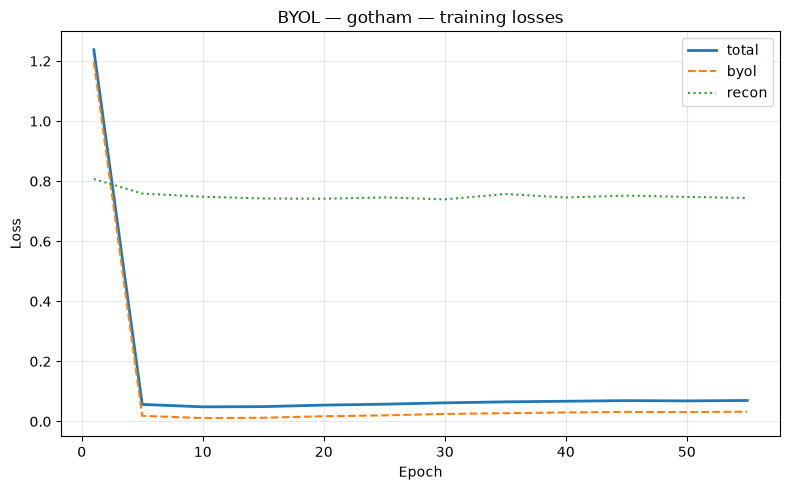

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_losses.png


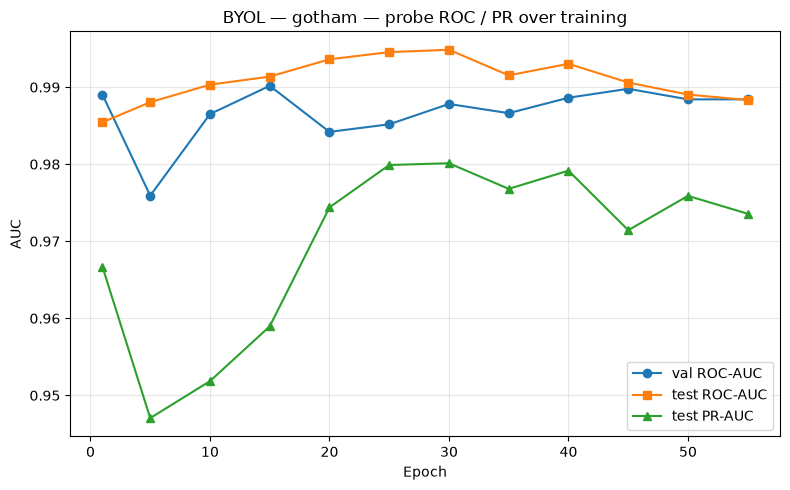

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_probe_roc_pr.png


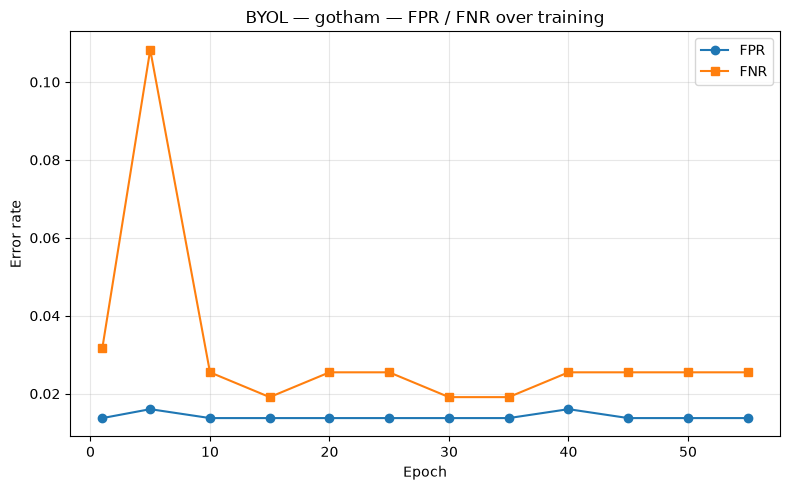

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_probe_fpr_fnr.png


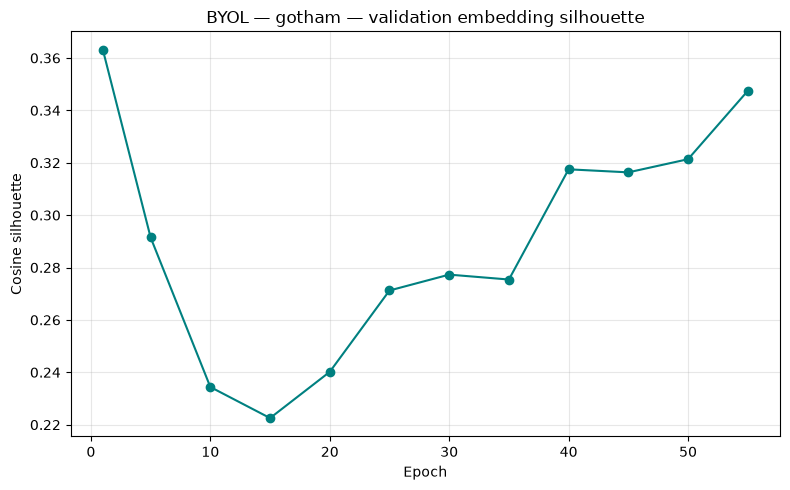

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_probe_silhouette.png


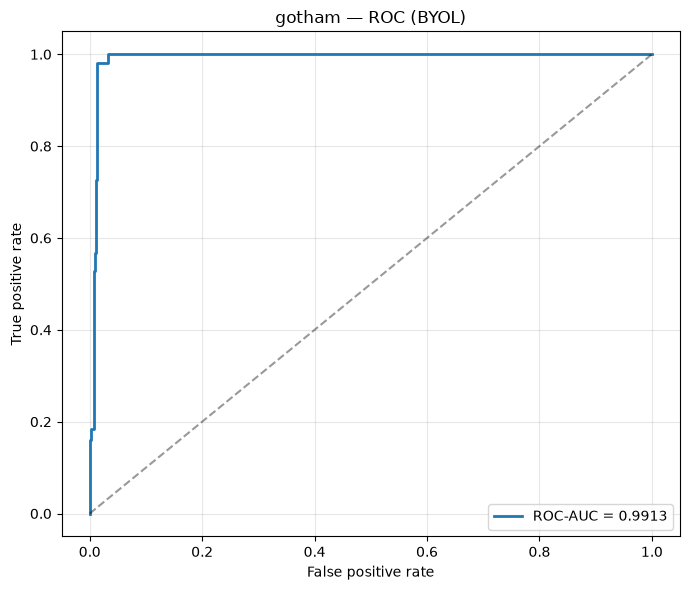

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_roc.png


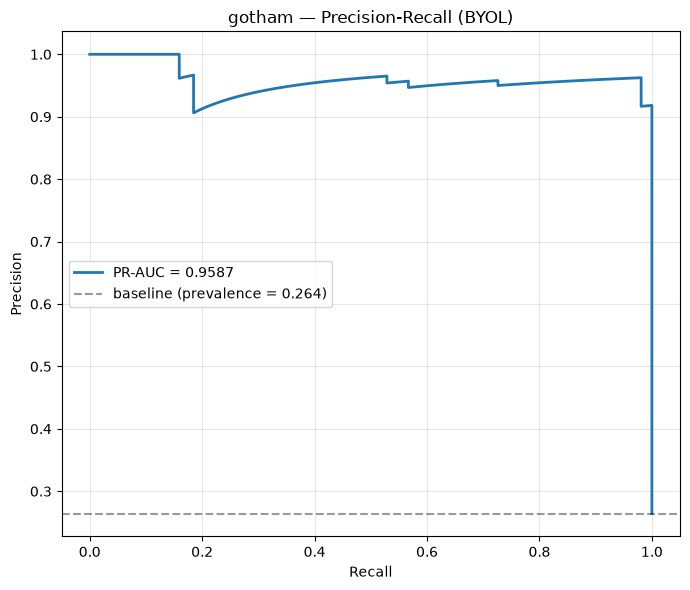

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_pr.png


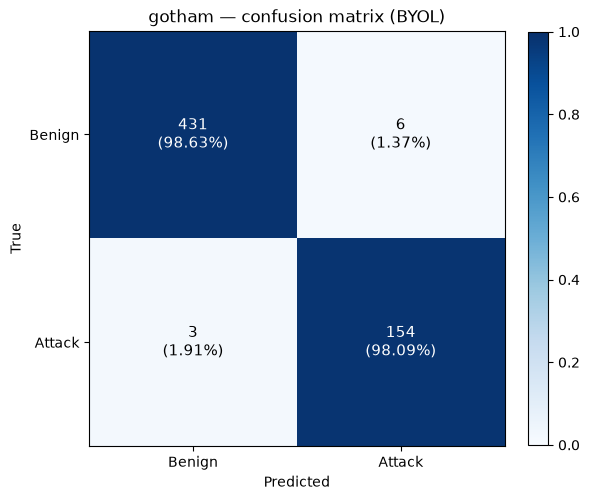

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_confusion.png


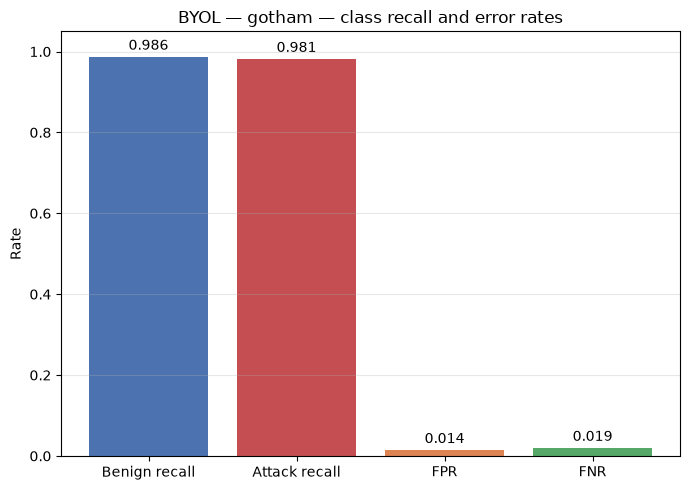

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_class_rates.png
[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_classification_report.txt
[plot] gotham: embedding 800 graphs ...


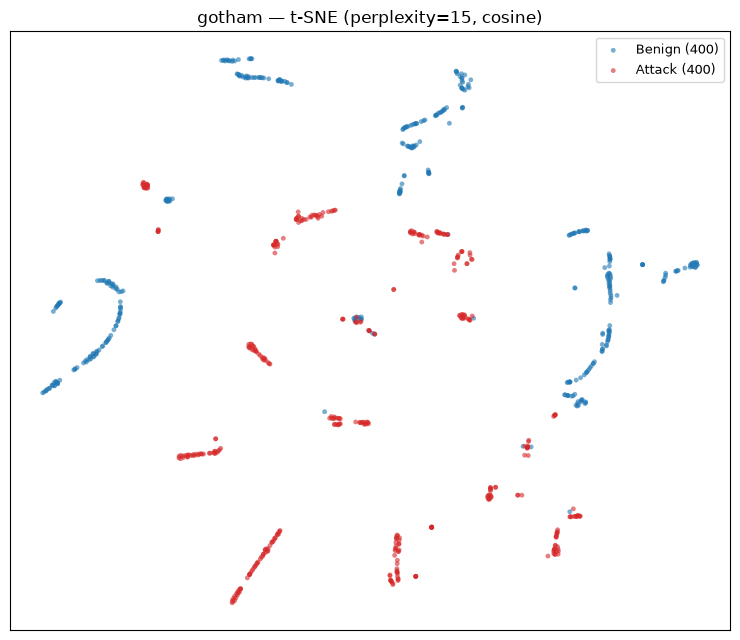

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_tsne_binary.png


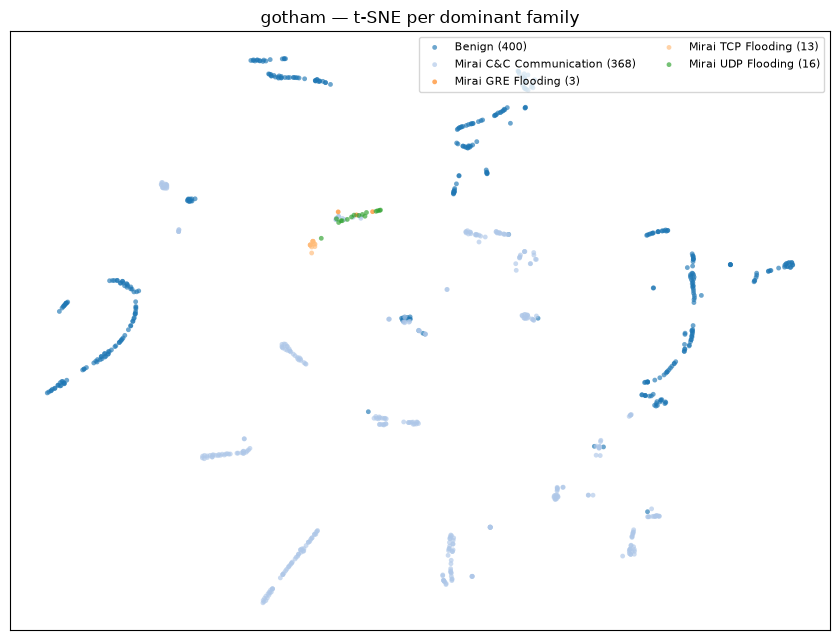

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_tsne_family.png


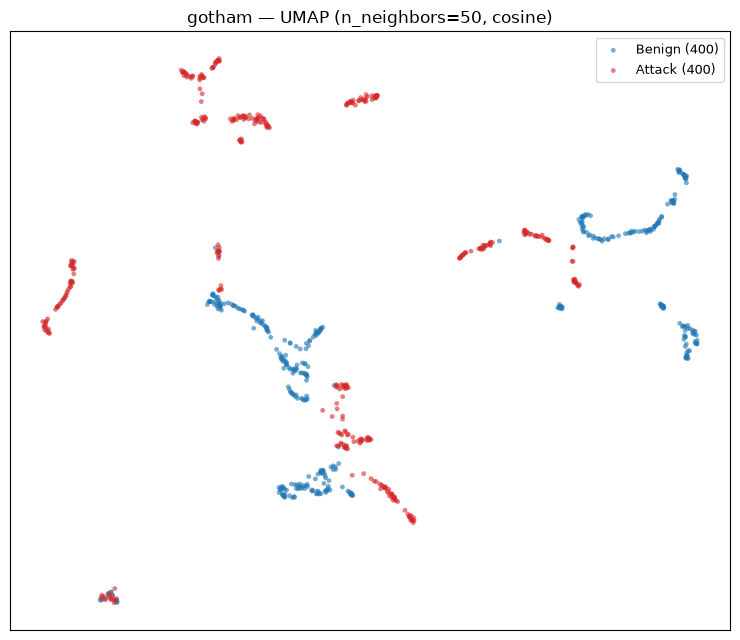

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_umap_binary.png


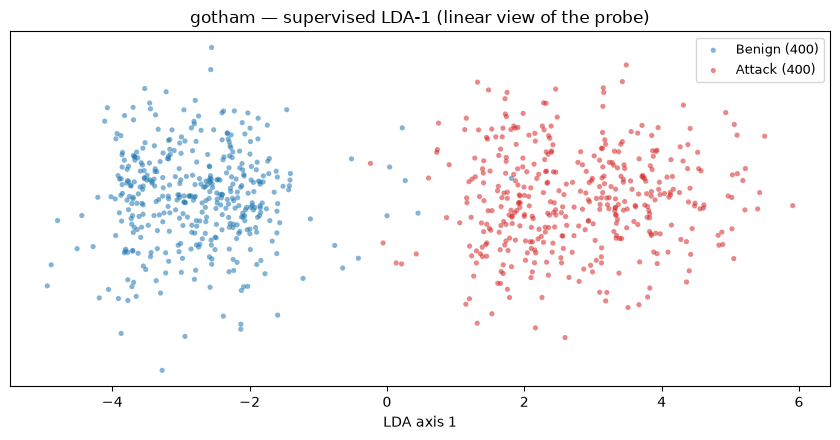

[plot] saved ssl_plots\BYOL\gotham\BYOL_gotham_lda.png
[cache] bundle 'nf_bot' already loaded

[plot] ==== BYOL · nf_bot ====


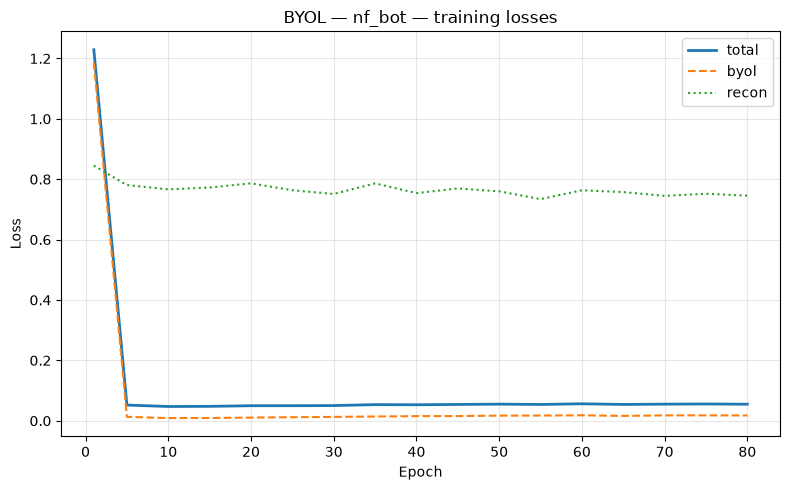

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_losses.png


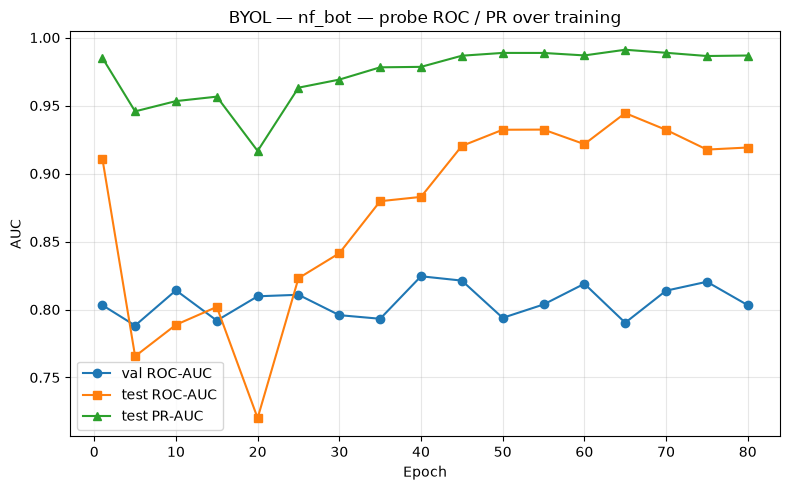

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_probe_roc_pr.png


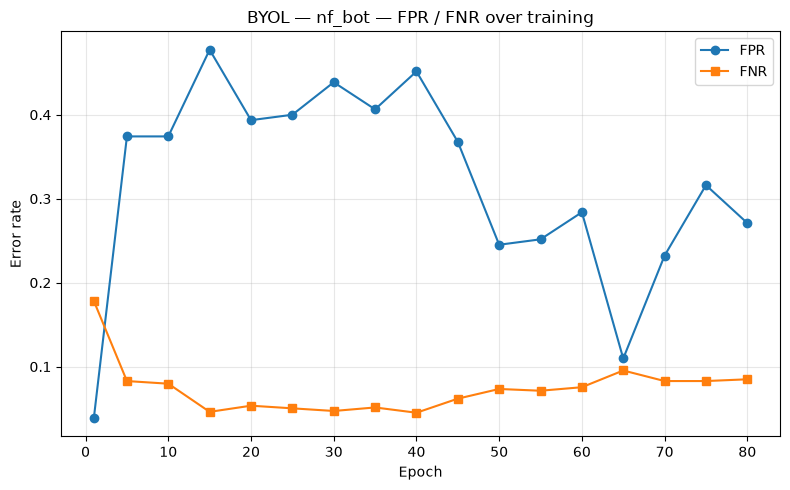

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_probe_fpr_fnr.png


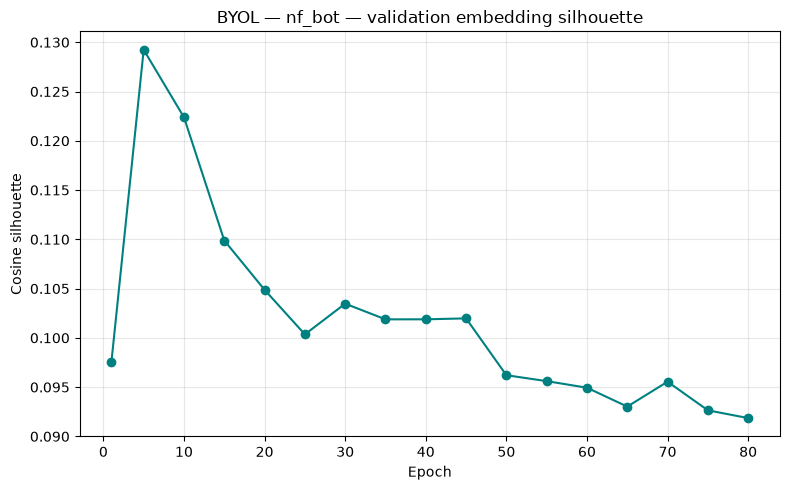

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_probe_silhouette.png


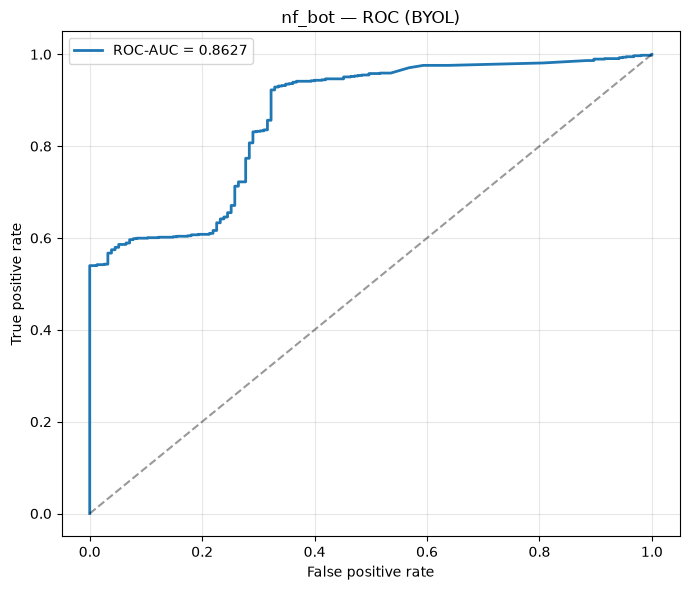

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_roc.png


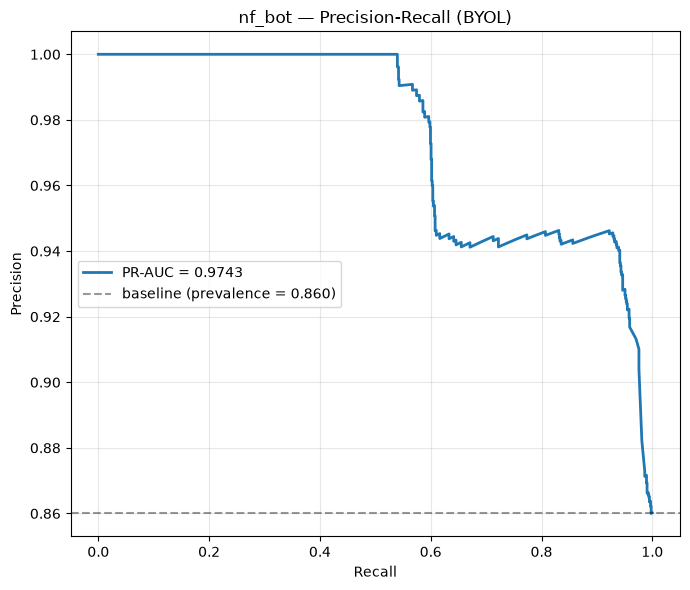

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_pr.png


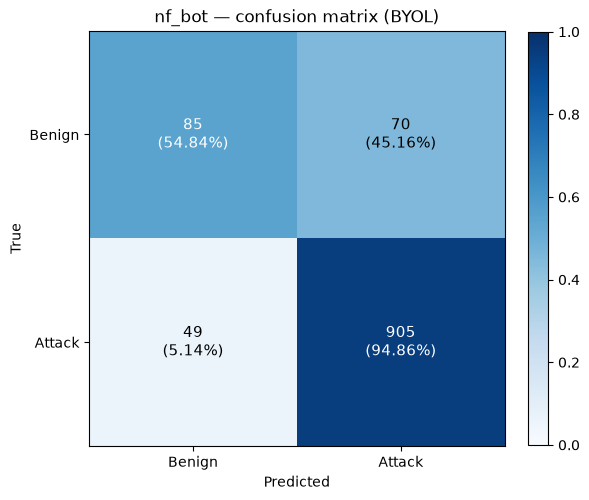

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_confusion.png


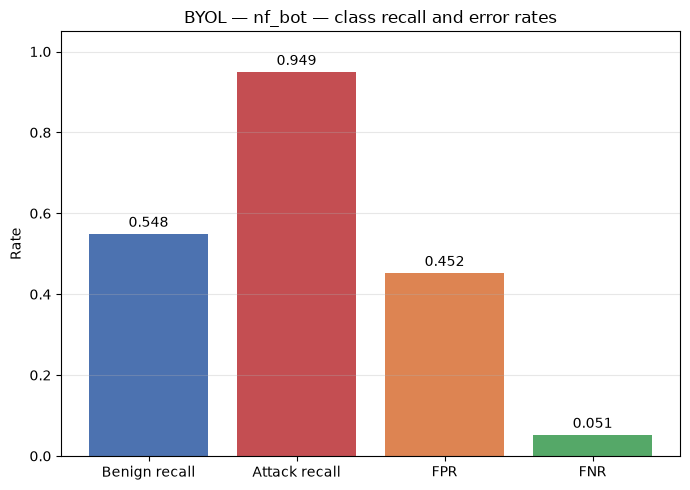

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_class_rates.png
[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_classification_report.txt
[plot] nf_bot: embedding 736 graphs ...


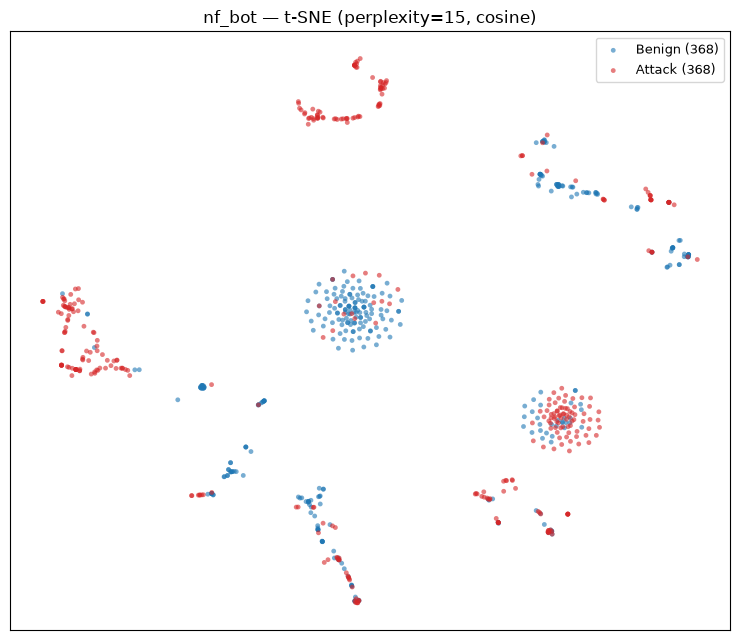

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_tsne_binary.png


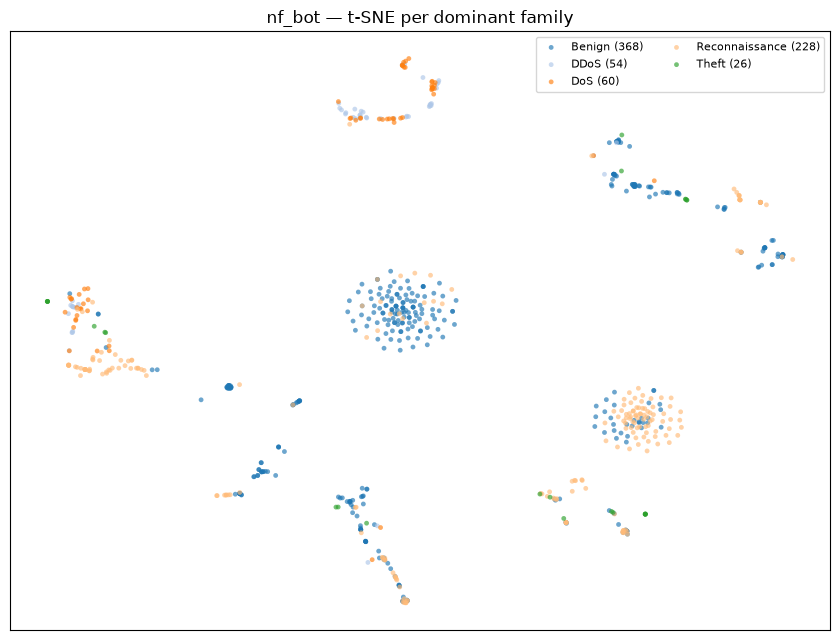

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_tsne_family.png


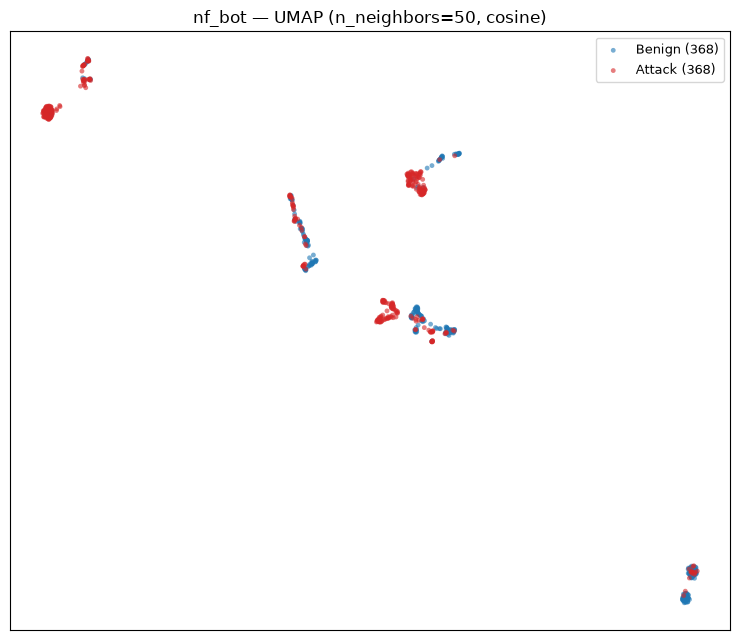

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_umap_binary.png


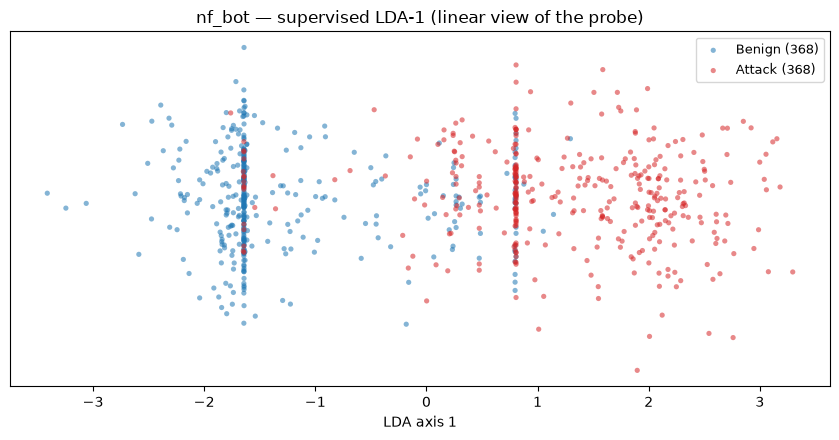

[plot] saved ssl_plots\BYOL\nf_bot\BYOL_nf_bot_lda.png
[cache] bundle 'nf_ton' already loaded

[plot] ==== BYOL · nf_ton ====


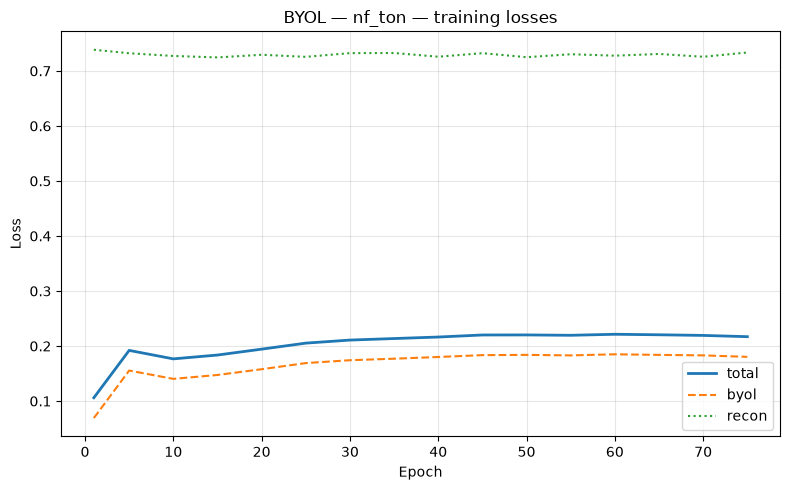

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_losses.png


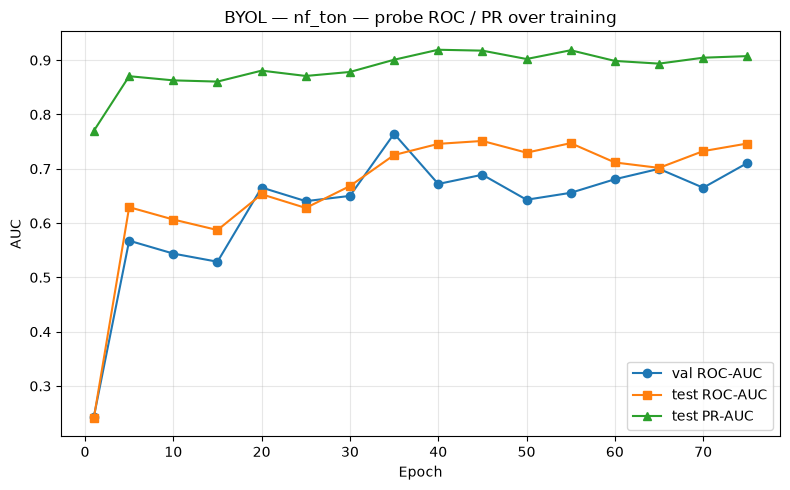

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_probe_roc_pr.png


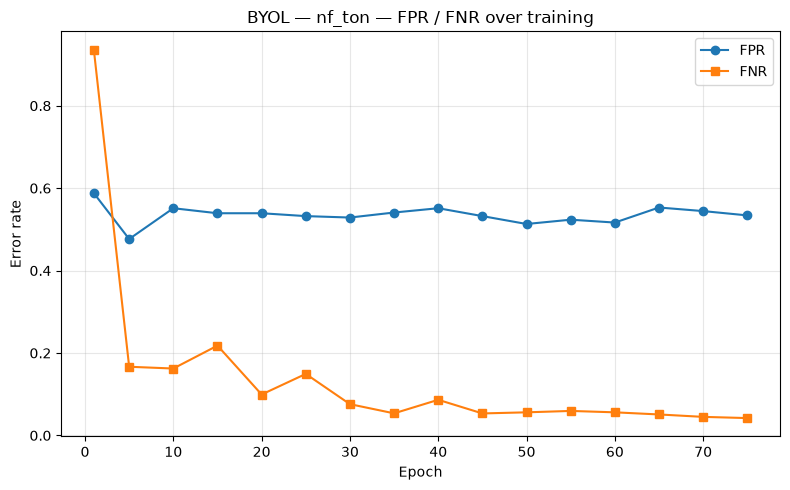

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_probe_fpr_fnr.png


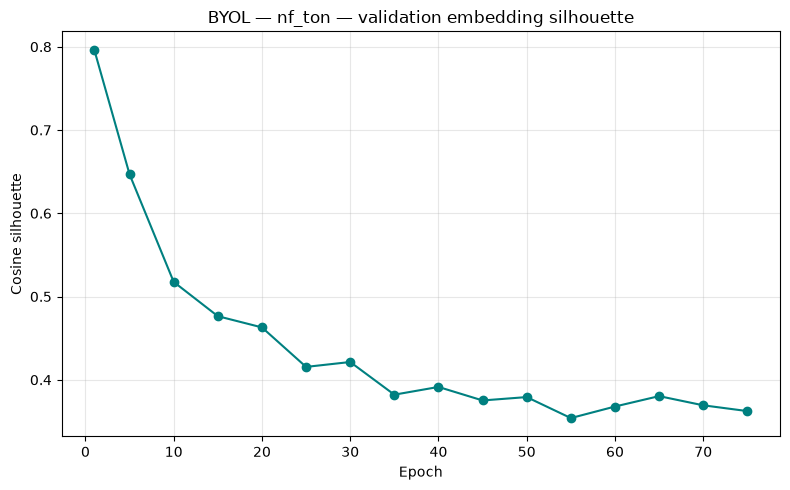

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_probe_silhouette.png


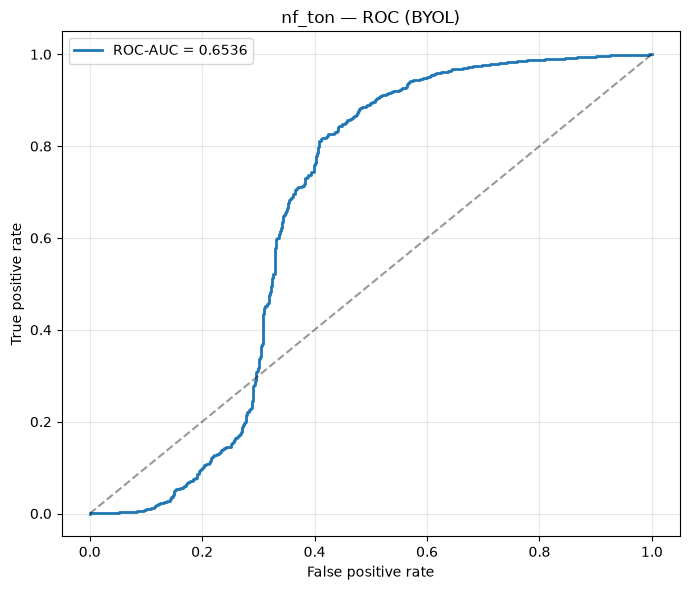

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_roc.png


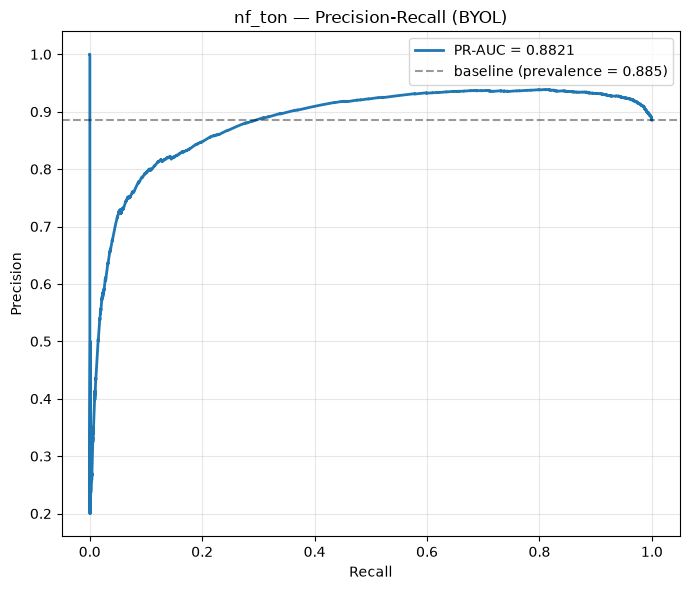

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_pr.png


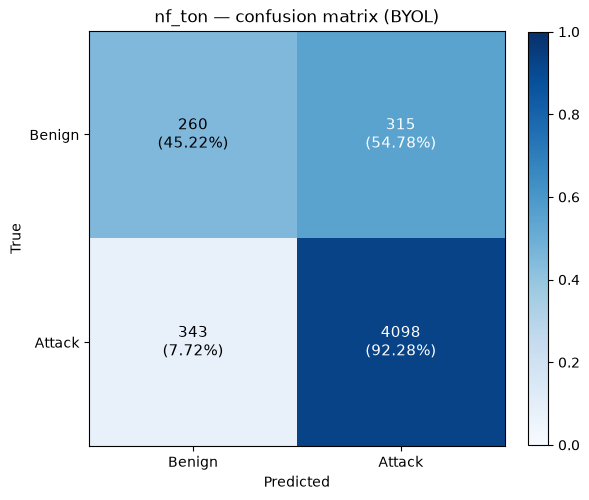

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_confusion.png


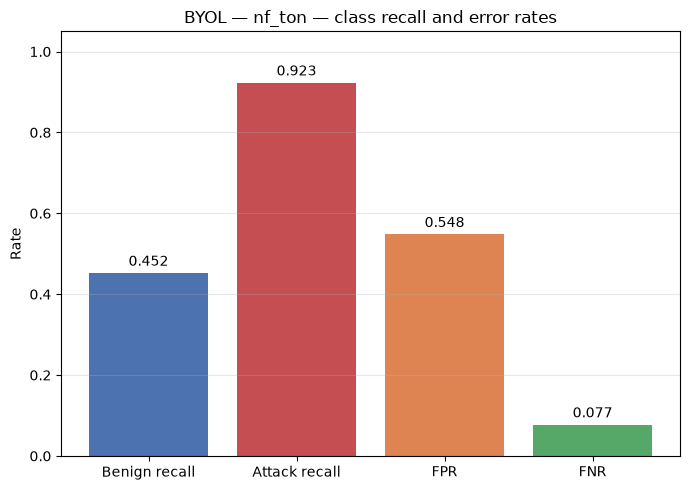

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_class_rates.png
[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_classification_report.txt
[plot] nf_ton: embedding 1806 graphs ...


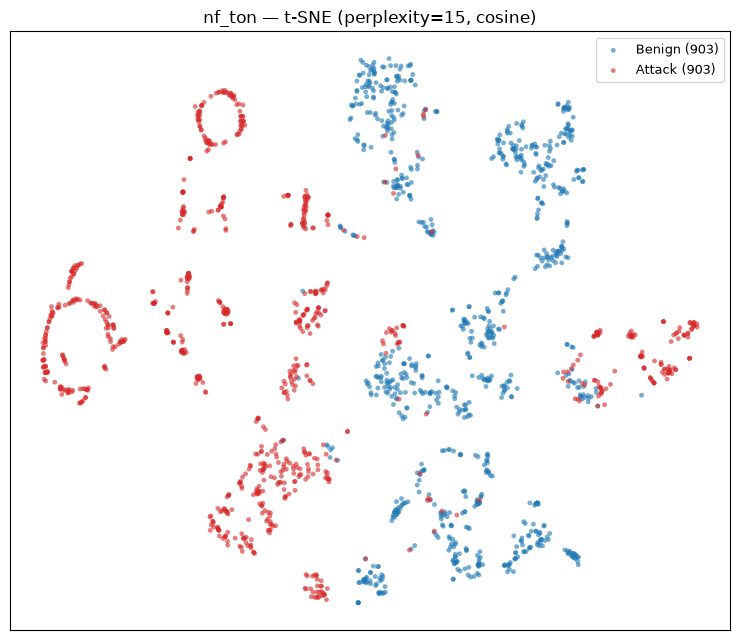

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_tsne_binary.png


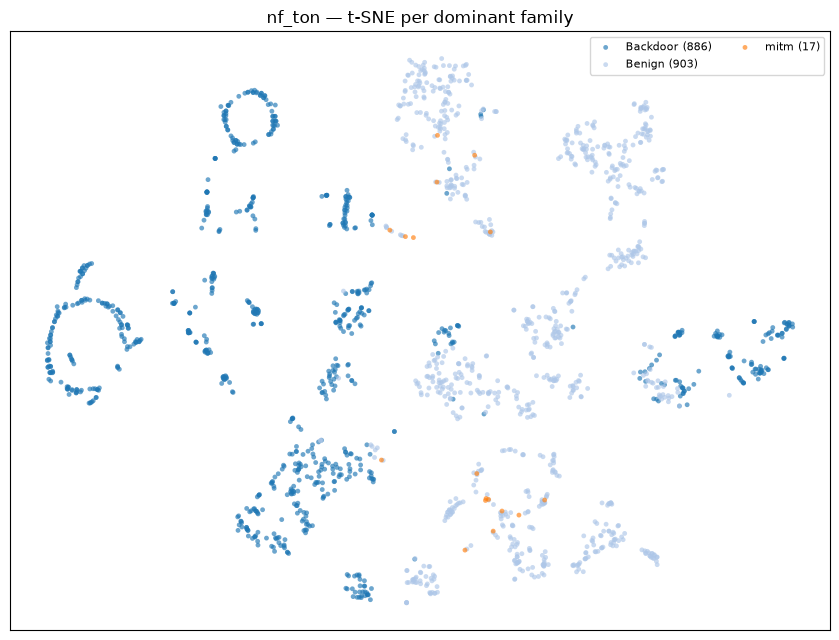

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_tsne_family.png


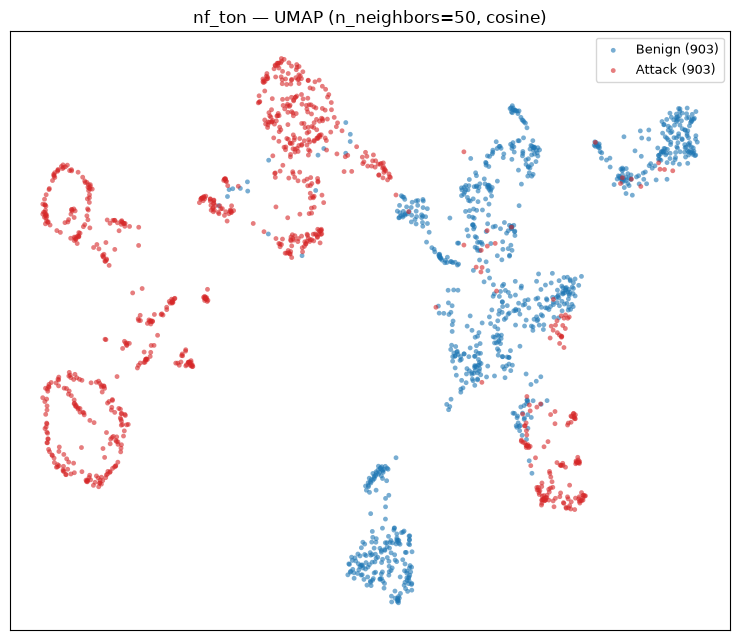

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_umap_binary.png


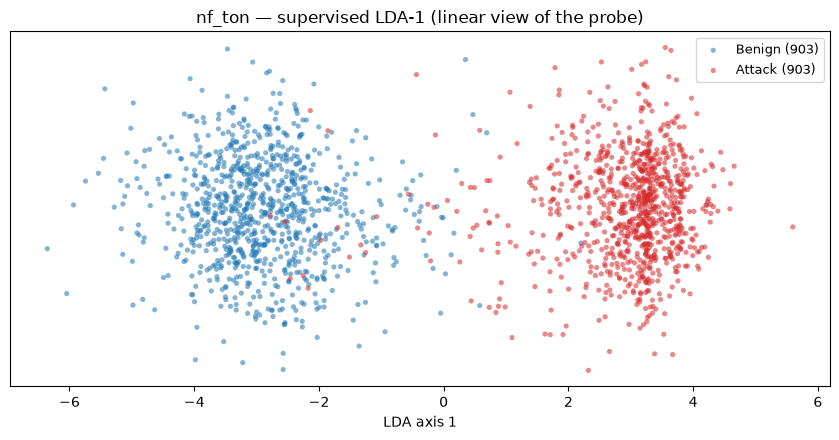

[plot] saved ssl_plots\BYOL\nf_ton\BYOL_nf_ton_lda.png


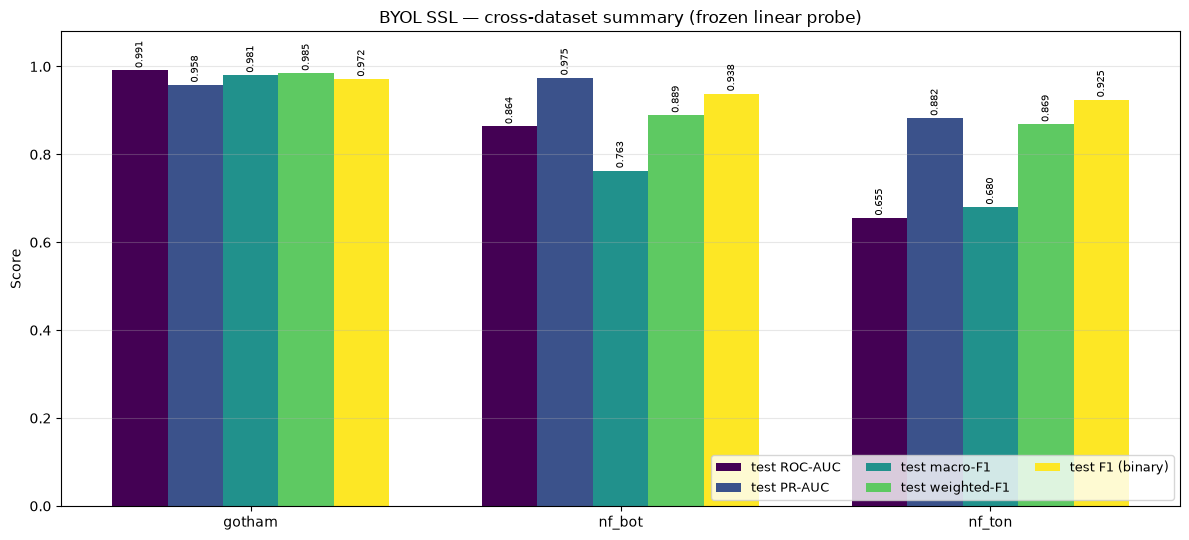

[plot] saved ssl_plots\BYOL\BYOL_cross_dataset_summary.png

[plot] done — everything under c:\Users\User\Desktop\MC-STGAT-IDS\MC-STGAT-IDS-V3\ssl_plots\BYOL/


In [24]:
# =====================================================================
# Single-cell plotting block — auto-detects BYOL vs MoCo
# =====================================================================
import os, gc, json
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report,
                             average_precision_score, roc_auc_score,
                             f1_score)

try:
    from umap import UMAP
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    print("[plot] umap-learn not installed — t-SNE only")

if 'byol_loss' in globals() or 'byol_momentum_schedule' in globals():
    METHOD = "BYOL"
elif 'info_nce_loss' in globals() or 'dequeue_and_enqueue' in globals() \
        or 'MoCoModel' in globals():
    METHOD = "MOCO"
else:
    raise RuntimeError("Cannot auto-detect METHOD — run the SSL notebook first.")

PLOT_ROOT = os.path.join("ssl_plots", METHOD)
os.makedirs(PLOT_ROOT, exist_ok=True)

def _plot_dir(dataset):
    p = os.path.join(PLOT_ROOT, dataset)
    os.makedirs(p, exist_ok=True)
    return p

def _nan_to_clean(X):
    return np.nan_to_num(X, nan=0.0, posinf=100.0, neginf=-100.0)

def probe_with_predictions(X_train, y_train, X_val, y_val, X_test, y_test):
    Xtr_raw = _nan_to_clean(X_train)
    Xva_raw = _nan_to_clean(X_val)
    Xte_raw = _nan_to_clean(X_test)
    scaler  = StandardScaler().fit(Xtr_raw)
    Xtr = scaler.transform(Xtr_raw)
    Xva = scaler.transform(Xva_raw)
    Xte = scaler.transform(Xte_raw)
    if len(set(y_train)) < 2:
        return None
    lr = LogisticRegression(max_iter=3000, class_weight='balanced',
                            n_jobs=-1).fit(Xtr, y_train)
    pv = lr.predict_proba(Xva)[:, 1]
    pt = lr.predict_proba(Xte)[:, 1]
    thr, _ = _optimal_threshold(pv, y_val)
    return dict(prob_val=pv, prob_test=pt,
                y_val=y_val, y_test=y_test, thr=float(thr))

def load_trained_encoder(bundle):
    ckpt = torch.load(bundle['encoder_path'], map_location=DEVICE)
    enc = GATEncoder(ckpt['node_dim'], ckpt['hidden_dim'], ckpt['num_heads'],
                     ckpt['num_layers'], ckpt['edge_dim']).to(DEVICE)
    enc.load_state_dict(ckpt['encoder_state_dict'])
    enc.eval()
    return enc

def _save_fig(fig, path):
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"[plot] saved {path}")

# ---------------------------------------------------------------------
# 1) Training curves — 4 separate figures (no F1, no momentum)
# ---------------------------------------------------------------------
def plot_training_curves(report, dataset, method):
    out_dir = _plot_dir(dataset)
    history = report.get('history', [])
    if not history:
        print(f"[plot] {dataset}: no history — skipping curves"); return

    ep = np.array([h['epoch'] for h in history], dtype=float)
    def _arr(k):
        return np.array([h[k] if h.get(k) is not None else np.nan
                         for h in history], dtype=float)

    loss    = _arr('train_loss')
    ssl_key = 'byol' if 'byol' in history[0] else 'nce'
    ssl     = _arr(ssl_key)
    rec     = _arr('recon')

    val_roc  = _arr('probe_val_roc')
    test_roc = _arr('probe_test_roc')
    test_pr  = _arr('probe_test_pr')
    test_fpr = _arr('probe_test_fpr')
    test_fnr = _arr('probe_test_fnr')
    sil      = _arr('probe_val_silhouette')

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep, loss, '-',  lw=2,   label='total')
    ax.plot(ep, ssl,  '--', lw=1.5, label=ssl_key)
    ax.plot(ep, rec,  ':',  lw=1.5, label='recon')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(f"{method} — {dataset} — training losses")
    ax.legend(); ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_losses.png"))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep, val_roc,  'o-', label='val ROC-AUC')
    ax.plot(ep, test_roc, 's-', label='test ROC-AUC')
    ax.plot(ep, test_pr,  '^-', label='test PR-AUC')
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.set_title(f"{method} — {dataset} — probe ROC / PR over training")
    ax.legend(); ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_probe_roc_pr.png"))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep, test_fpr, 'o-', label='FPR')
    ax.plot(ep, test_fnr, 's-', label='FNR')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Error rate")
    ax.set_title(f"{method} — {dataset} — FPR / FNR over training")
    ax.legend(); ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_probe_fpr_fnr.png"))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep, sil, 'o-', color='teal')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Cosine silhouette")
    ax.set_title(f"{method} — {dataset} — validation embedding silhouette")
    ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_probe_silhouette.png"))

# ---------------------------------------------------------------------
# 2) ROC and PR — separate figures
# ---------------------------------------------------------------------
def plot_roc_pr(encoder, bundle, dataset, method):
    out_dir = _plot_dir(dataset)
    X_train = embed_graphs(encoder, bundle['train_graphs'], DEVICE)
    X_val   = embed_graphs(encoder, bundle['val_graphs'],   DEVICE)
    X_test  = embed_graphs(encoder, bundle['test_graphs'],  DEVICE)

    p = probe_with_predictions(X_train, bundle['train_bin'],
                               X_val,   bundle['val_bin'],
                               X_test,  bundle['test_bin'])
    if p is None:
        print(f"[plot] {dataset}: single-class train — skipping ROC/PR"); return

    fpr, tpr, _ = roc_curve(p['y_test'], p['prob_test'])
    roc_auc     = roc_auc_score(p['y_test'], p['prob_test'])
    prec, rec, _ = precision_recall_curve(p['y_test'], p['prob_test'])
    pr_auc       = average_precision_score(p['y_test'], p['prob_test'])
    base         = p['y_test'].mean()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, lw=2, label=f"ROC-AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], 'k--', alpha=.4)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"{dataset} — ROC ({method})")
    ax.legend(); ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_roc.png"))

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(rec, prec, lw=2, label=f"PR-AUC = {pr_auc:.4f}")
    ax.axhline(base, color='k', ls='--', alpha=.4,
               label=f"baseline (prevalence = {base:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{dataset} — Precision-Recall ({method})")
    ax.legend(); ax.grid(alpha=.3)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_pr.png"))

    del X_train, X_val, X_test
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

# ---------------------------------------------------------------------
# 3) Confusion matrix and class-rate bar
# ---------------------------------------------------------------------
def plot_confusion_and_class_report(encoder, bundle, dataset, method):
    out_dir = _plot_dir(dataset)
    X_train = embed_graphs(encoder, bundle['train_graphs'], DEVICE)
    X_val   = embed_graphs(encoder, bundle['val_graphs'],   DEVICE)
    X_test  = embed_graphs(encoder, bundle['test_graphs'],  DEVICE)

    p = probe_with_predictions(X_train, bundle['train_bin'],
                               X_val,   bundle['val_bin'],
                               X_test,  bundle['test_bin'])
    if p is None:
        print(f"[plot] {dataset}: single-class train — skipping confusion"); return

    y_true = p['y_test']
    y_pred = (p['prob_test'] >= p['thr']).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    recall_benign = cm[0, 0] / max(cm[0].sum(), 1)
    recall_attack = cm[1, 1] / max(cm[1].sum(), 1)
    fpr           = cm[0, 1] / max(cm[0].sum(), 1)
    fnr           = cm[1, 0] / max(cm[1].sum(), 1)

    fig, ax = plt.subplots(figsize=(6, 5.5))
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]}\n({cmn[i,j]:.2%})",
                    ha='center', va='center',
                    color='white' if cmn[i, j] > 0.5 else 'black',
                    fontsize=11)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Attack'])
    ax.set_yticklabels(['Benign', 'Attack'])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{dataset} — confusion matrix ({method})")
    plt.colorbar(im, ax=ax, fraction=0.045)
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_confusion.png"))

    fig, ax = plt.subplots(figsize=(7, 5))
    labels = ['Benign recall', 'Attack recall', 'FPR', 'FNR']
    values = [recall_benign, recall_attack, fpr, fnr]
    colors = ['#4C72B0', '#C44E52', '#DD8452', '#55A868']
    bars = ax.bar(labels, values, color=colors)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}",
                ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate")
    ax.set_title(f"{method} — {dataset} — class recall and error rates")
    ax.grid(alpha=.3, axis='y')
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_class_rates.png"))

    rep = classification_report(y_true, y_pred,
                                target_names=['Benign', 'Attack'],
                                digits=4, zero_division=0)
    txt_path = os.path.join(out_dir,
                            f"{method}_{dataset}_classification_report.txt")
    with open(txt_path, 'w') as f:
        f.write(f"{method} — {dataset} — test set\n")
        f.write(f"threshold = {p['thr']:.4f}\n\n{rep}")
    print(f"[plot] saved {txt_path}")

    del X_train, X_val, X_test
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

# ---------------------------------------------------------------------
# 4) Embeddings — cosine-aligned, no misclassified overlay
# ---------------------------------------------------------------------
def plot_embeddings(encoder, bundle, dataset, method,
                    max_points=3000, seed=SEED):
    out_dir = _plot_dir(dataset)
    rng = np.random.default_rng(seed)

    val_g  = bundle['val_graphs'];   val_y  = bundle['val_bin']
    test_g = bundle['test_graphs'];  test_y = bundle['test_bin']

    def _balanced_idx(y, k):
        idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
        k_half = min(k // 2, len(idx0), len(idx1))
        if k_half == 0:
            k_half = min(k, max(len(idx0), len(idx1)))
        s0 = rng.choice(idx0, min(k_half, len(idx0)), replace=False)
        s1 = rng.choice(idx1, min(k_half, len(idx1)), replace=False)
        return np.concatenate([s0, s1])

    idx_v = _balanced_idx(val_y,  max_points // 2)
    idx_t = _balanced_idx(test_y, max_points // 2)

    sub_val  = [val_g[i]  for i in idx_v];  y_val_sub  = val_y[idx_v]
    sub_test = [test_g[i] for i in idx_t];  y_test_sub = test_y[idx_t]

    def _fam(g):
        try:
            return dominant_family(g, bundle['attack_threshold'])
        except Exception:
            return 'Benign'

    fam_val  = np.array([_fam(g) for g in sub_val])
    fam_test = np.array([_fam(g) for g in sub_test])

    print(f"[plot] {dataset}: embedding {len(sub_val) + len(sub_test)} graphs ...")
    X_val_e  = embed_graphs(encoder, sub_val,  DEVICE)
    X_test_e = embed_graphs(encoder, sub_test, DEVICE)
    X_raw = np.vstack([X_val_e, X_test_e])
    y_bin = np.concatenate([y_val_sub,  y_test_sub])
    y_fam = np.concatenate([fam_val,    fam_test])

    # L2-normalise (matches MoCo's cosine objective)
    X = X_raw / np.clip(np.linalg.norm(X_raw, axis=1, keepdims=True), 1e-8, None)

    # PCA(30) on cosine-normalised features, then L2 again
    n_pca = min(30, X.shape[1] - 1, X.shape[0] - 1)
    Xp = PCA(n_components=n_pca, random_state=seed).fit_transform(X)
    Xp = Xp / np.clip(np.linalg.norm(Xp, axis=1, keepdims=True), 1e-8, None)

    perp = min(15, max(5, (len(Xp) - 1) // 3))

    # --- Figure 1: t-SNE binary ---
    tsne = TSNE(n_components=2, perplexity=perp, init='pca',
                learning_rate='auto', metric='cosine',
                random_state=seed).fit_transform(Xp)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    for c, lbl, col in [(0, 'Benign', '#1f77b4'), (1, 'Attack', '#d62728')]:
        m = y_bin == c
        ax.scatter(tsne[m, 0], tsne[m, 1], s=12, c=col, alpha=0.6,
                   label=f"{lbl} ({m.sum()})", edgecolors='none')
    ax.set_title(f"{dataset} — t-SNE (perplexity={perp}, cosine)")
    ax.legend(fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_tsne_binary.png"))

    # --- Figure 2: t-SNE per family ---
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    uniq = sorted(set(y_fam))
    cmap = plt.get_cmap('tab20')
    fam_colors = {f: cmap(i % 20) for i, f in enumerate(uniq)}
    for f in uniq:
        m = y_fam == f
        ax.scatter(tsne[m, 0], tsne[m, 1], s=12,
                   color=fam_colors[f], alpha=0.65,
                   label=f"{f} ({m.sum()})", edgecolors='none')
    ax.set_title(f"{dataset} — t-SNE per dominant family")
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.set_xticks([]); ax.set_yticks([])
    _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_tsne_family.png"))

    # --- Figure 3: UMAP binary (cosine, global) ---
    if HAS_UMAP:
        try:
            umap2d = UMAP(n_components=2, n_neighbors=50, min_dist=0.3,
                          metric='cosine',
                          random_state=seed).fit_transform(Xp)
            fig, ax = plt.subplots(figsize=(7.5, 6.5))
            for c, lbl, col in [(0, 'Benign', '#1f77b4'), (1, 'Attack', '#d62728')]:
                m = y_bin == c
                ax.scatter(umap2d[m, 0], umap2d[m, 1], s=12, c=col,
                           alpha=0.6, label=f"{lbl} ({m.sum()})",
                           edgecolors='none')
            ax.set_title(f"{dataset} — UMAP (n_neighbors=50, cosine)")
            ax.legend(fontsize=9); ax.set_xticks([]); ax.set_yticks([])
            _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_umap_binary.png"))
        except Exception as e:
            print(f"[plot] UMAP failed ({e}); skipping UMAP panel")

    # --- Figure 4: supervised LDA-1 (what the probe sees) ---
    if len(set(y_bin)) == 2:
        try:
            Xs2  = StandardScaler().fit_transform(X)
            lda1 = LinearDiscriminantAnalysis(n_components=1)\
                     .fit_transform(Xs2, y_bin)
            jitter = rng.normal(0, 0.02, size=(len(lda1), 1))
            lda2d  = np.hstack([lda1, jitter])
            fig, ax = plt.subplots(figsize=(8.5, 4.5))
            for c, lbl, col in [(0, 'Benign', '#1f77b4'), (1, 'Attack', '#d62728')]:
                m = y_bin == c
                ax.scatter(lda2d[m, 0], lda2d[m, 1], s=14, c=col, alpha=0.55,
                           label=f"{lbl} ({m.sum()})", edgecolors='none')
            ax.set_title(f"{dataset} — supervised LDA-1 (linear view of the probe)")
            ax.set_yticks([]); ax.set_xlabel("LDA axis 1")
            ax.legend(fontsize=9)
            _save_fig(fig, os.path.join(out_dir, f"{method}_{dataset}_lda.png"))
        except Exception as e:
            print(f"[plot] LDA failed ({e}); skipping LDA panel")

    del X, Xp, X_raw, tsne, X_val_e, X_test_e
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

# ---------------------------------------------------------------------
# 5) Cross-dataset summary
# ---------------------------------------------------------------------
def plot_cross_dataset_summary(all_reports, method):
    datasets = [d for d, r in all_reports.items() if 'error' not in r]
    if not datasets:
        print("[plot] no reports to summarise"); return

    metrics = [
        ('test_roc_auc',     'test ROC-AUC'),
        ('test_pr_auc',      'test PR-AUC'),
        ('test_macro_f1',    'test macro-F1'),
        ('test_weighted_f1', 'test weighted-F1'),
        ('test_f1_binary',   'test F1 (binary)'),
    ]

    x = np.arange(len(datasets)); w = 0.15
    fig, ax = plt.subplots(figsize=(12, 5.5))
    cmap = plt.get_cmap('viridis')
    for i, (key, name) in enumerate(metrics):
        vals = [float(all_reports[d].get(key, np.nan)) for d in datasets]
        bars = ax.bar(x + (i - len(metrics) / 2 + 0.5) * w,
                      vals, width=w, label=name,
                      color=cmap(i / max(len(metrics) - 1, 1)))
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                    f"{v:.3f}", ha='center', va='bottom',
                    fontsize=7, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(datasets)
    ax.set_ylim(0, 1.08); ax.set_ylabel("Score")
    ax.set_title(f"{method} SSL — cross-dataset summary (frozen linear probe)")
    ax.legend(loc='lower right', ncol=3, fontsize=9)
    ax.grid(alpha=.3, axis='y')
    _save_fig(fig, os.path.join(PLOT_ROOT, f"{method}_cross_dataset_summary.png"))

# ---------------------------------------------------------------------
# 6) Driver
# ---------------------------------------------------------------------
print(f"\n[plot] METHOD auto-detected = {METHOD}")
print(f"[plot] outputs  >  {os.path.abspath(PLOT_ROOT)}/\n")

for _ds in ['gotham', 'nf_bot', 'nf_ton']:
    bundle = load_dataset_bundle(_ds)
    if not os.path.isfile(bundle['encoder_path']):
        print(f"[plot] {_ds}: no encoder checkpoint — skipping"); continue

    print(f"\n[plot] ==== {METHOD} · {_ds} ====")
    enc = load_trained_encoder(bundle)

    try:
        _rep = all_ssl_reports.get(_ds)
        if _rep is None and os.path.isfile(bundle['report_path']):
            with open(bundle['report_path']) as f:
                _rep = json.load(f)
        if _rep is not None and 'error' not in _rep:
            plot_training_curves(_rep, _ds, METHOD)

        plot_roc_pr(enc, bundle, _ds, METHOD)
        plot_confusion_and_class_report(enc, bundle, _ds, METHOD)
        plot_embeddings(enc, bundle, _ds, METHOD, max_points=3000)
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"[plot] {_ds} failed: {e}")

    del enc
    gc.collect()
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

plot_cross_dataset_summary(all_ssl_reports, METHOD)

print(f"\n[plot] done — everything under {os.path.abspath(PLOT_ROOT)}/")